In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, DoubleType

In [2]:
hotel_recommendation_path = kagglehub.competition_download('expedia-hotel-recommendations')
print("Path to competition files:", hotel_recommendation_path)
yelp_review_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")
print("Path to Yelp review files:", yelp_review_path)
taxi_trajectory_path = kagglehub.dataset_download("crailtap/taxi-trajectory")
print("Path to taxi trajectory files:", taxi_trajectory_path)
akeed_restaurant_path = kagglehub.dataset_download("darisdzakwanhoesien2/akeed-restaurant-recommendation-challenge")
print("Path to taxi trajectory files:", akeed_restaurant_path)
for dirname, _, filenames in os.walk(hotel_recommendation_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
for dirname, _, filenames in os.walk(yelp_review_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
for dirname, _, filenames in os.walk(taxi_trajectory_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))
for dirname, _, filenames in os.walk(akeed_restaurant_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Path to competition files: /Users/phamminh/.cache/kagglehub/competitions/expedia-hotel-recommendations
Path to Yelp review files: /Users/phamminh/.cache/kagglehub/datasets/yelp-dataset/yelp-dataset/versions/4
Path to taxi trajectory files: /Users/phamminh/.cache/kagglehub/datasets/crailtap/taxi-trajectory/versions/1
Path to taxi trajectory files: /Users/phamminh/.cache/kagglehub/datasets/darisdzakwanhoesien2/akeed-restaurant-recommendation-challenge/versions/1
/Users/phamminh/.cache/kagglehub/competitions/expedia-hotel-recommendations/destinations.csv
/Users/phamminh/.cache/kagglehub/competitions/expedia-hotel-recommendations/test.csv
/Users/phamminh/.cache/kagglehub/competitions/expedia-hotel-recommendations/train.csv
/Users/phamminh/.cache/kagglehub/competitions/expedia-hotel-recommendations/sample_submission.csv
/Users/phamminh/.cache/kagglehub/datasets/yelp-dataset/yelp-dataset/versions/4/yelp_academic_dataset_checkin.json
/Users/phamminh/.cache/kagglehub/datasets/yelp-dataset/yelp

In [3]:

# macOS has no system Java by default; point PySpark at the Homebrew-installed JDK.
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21/libexec/openjdk.jdk/Contents/Home"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Pin PySpark's driver/worker Python to this kernel's interpreter so their
# versions match (otherwise Spark picks whatever "python3" resolves to on PATH).
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# In local mode driver and executor share one JVM, so spark.driver.memory is what
# actually matters. Keep this conservative - on a loaded machine the OS will
# silently SIGKILL the JVM if it can't back the requested heap, which shows up
# later as a ConnectionRefusedError/Py4J failure with no obvious cause. If you
# still see that error, check `ps aux | grep java` (empty = JVM died, not a code
# bug) and either lower this further or free up RAM (browser tabs, other apps).
#
# spark.memory.storageFraction is lowered from Spark's 0.5 default because
# hotel_rec_train.persist(...) elsewhere in this notebook otherwise reserves a
# protected chunk of the heap for cached data that execution (sorts, shuffles,
# window functions) can't reclaim even under memory pressure - that's what
# caused the "Java heap space" OOM in the gap-based session cell. Lowering it
# lets a persisted DataFrame spill more readily to disk instead of starving
# other operations. spark.sql.shuffle.partitions is raised from the 200 default
# so each shuffle task handles a smaller slice of the 37M-row dataset.
#
# spark.driver.host/bindAddress are pinned to loopback because this is local[*]
# mode on a single machine - there's no reason to bind to the machine's real
# WiFi/VPN-facing IP. Without this, Spark auto-detects that IP once at startup;
# if you switch networks (WiFi, VPN) afterward while the kernel keeps running,
# the old address stops existing on the machine and shuffle/block-transfer
# connections fail with "Can't assign requested address" (NativeIoException).
#
# NOTE: these are JVM-launch settings - if a SparkSession is already running in
# this kernel, restart the kernel (or spark.stop() and re-run this cell) for
# them to apply.
spark = (
    SparkSession.builder.appName("next-best-product")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.maxResultSize", "1g")
    .config("spark.memory.storageFraction", "0.3")
    .config("spark.sql.shuffle.partitions", "400")
    .getOrCreate()
)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 16:44:23 WARN Utils: Your hostname, MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.35 instead (on interface en0)
26/09/18 16:44:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/18 16:44:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# I. Expedia Hotel Recommendations

In [4]:
from pyspark import StorageLevel

destinations = spark.read.csv(os.path.join(hotel_recommendation_path, "destinations.csv"), header=True, inferSchema=True)
hotel_rec_train = spark.read.csv(os.path.join(hotel_recommendation_path, "train.csv"), header=True, inferSchema=True)
hotel_rec_test = spark.read.csv(os.path.join(hotel_recommendation_path, "test.csv"), header=True, inferSchema=True)

# hotel_rec_train is a 37M-row / ~4GB CSV re-parsed from disk on every downstream
# action; it's reused across most of section II, so cache it once here. MEMORY_AND_DISK
# spills to disk instead of dropping the cache (and warning) if it doesn't fully fit in RAM.
hotel_rec_train.persist(StorageLevel.MEMORY_AND_DISK)


DataFrame[date_time: timestamp, site_name: int, posa_continent: int, user_location_country: int, user_location_region: int, user_location_city: int, orig_destination_distance: double, user_id: int, is_mobile: int, is_package: int, channel: int, srch_ci: date, srch_co: date, srch_adults_cnt: int, srch_children_cnt: int, srch_rm_cnt: int, srch_destination_id: int, srch_destination_type_id: int, is_booking: int, cnt: int, hotel_continent: int, hotel_country: int, hotel_market: int, hotel_cluster: int]

In [5]:
hotel_rec_train.show()

+-------------------+---------+--------------+---------------------+--------------------+------------------+-------------------------+-------+---------+----------+-------+----------+----------+---------------+-----------------+-----------+-------------------+------------------------+----------+---+---------------+-------------+------------+-------------+
|          date_time|site_name|posa_continent|user_location_country|user_location_region|user_location_city|orig_destination_distance|user_id|is_mobile|is_package|channel|   srch_ci|   srch_co|srch_adults_cnt|srch_children_cnt|srch_rm_cnt|srch_destination_id|srch_destination_type_id|is_booking|cnt|hotel_continent|hotel_country|hotel_market|hotel_cluster|
+-------------------+---------+--------------+---------------------+--------------------+------------------+-------------------------+-------+---------+----------+-------+----------+----------+---------------+-----------------+-----------+-------------------+------------------------+--

In [6]:
destinations.show()

26/09/17 16:51:06 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+----

In [7]:
destinations_shape = (destinations.count(), len(destinations.columns))
destinations_shape

(62106, 150)

In [8]:
embedded_destinations = destinations.select(
    *[c for c in destinations.columns if c != "srch_destination_id"]
)
result = embedded_destinations.select(
    *[
        F.min(F.least(*embedded_destinations.columns)).alias("min"),
        F.max(F.greatest(*embedded_destinations.columns)).alias("max"),
    ]
)

result.show()

+--------------+---------------+
|           min|            max|
+--------------+---------------+
|-2.67161285968|-0.914404340588|
+--------------+---------------+



In [19]:
from pyspark import StorageLevel
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

vec_assembler = VectorAssembler(inputCols = embedded_destinations.columns,
                                outputCol='features')
vectorized_embed_destinations = vec_assembler.transform(destinations)
scaler = StandardScaler(inputCol="features",
                        outputCol="scaledFeatures",
                        withStd=True,
                        withMean=True)

scalerModel = scaler.fit(vectorized_embed_destinations)
normalized_destinations = scalerModel.transform(vectorized_embed_destinations)

# The silhouette/WSSSE loop below calls .fit() on this 9 times (k=2..9); without
# caching, each call re-runs the full destinations read + assemble + scale pipeline
# from scratch. Persist once here so those 9 fits reuse the same materialized data.
normalized_destinations.persist(StorageLevel.MEMORY_AND_DISK)

normalized_destinations.select('scaledFeatures').show(5)

+--------------------+
|      scaledFeatures|
+--------------------+
|[-0.1232347328041...|
|[0.31659638264968...|
|[0.26995001069950...|
|[0.42757599263221...|
|[0.11254589511514...|
+--------------------+
only showing top 5 rows


In [10]:
normalized_destinations.select('scaledFeatures').first()

Row(scaledFeatures=DenseVector([-0.1232, 0.1022, 0.2178, -0.1115, -0.5614, 1.086, 0.0971, 0.1244, 1.062, -0.1543, -0.6943, 0.2635, -0.4831, -0.8029, 0.2781, 1.9639, -0.3424, 0.0421, 0.2001, -0.1037, -0.0044, 0.0505, 0.2713, 0.0699, 0.1794, 0.1187, -0.1958, 0.2082, -0.9275, -0.1009, 0.2631, 0.0698, 0.1889, -0.2539, -0.2819, 0.134, -0.0678, -0.0045, 0.1907, 0.1989, -0.4152, 0.1427, 1.2897, -0.0883, -0.144, 0.2023, -0.0535, 0.0973, -1.1441, -0.0033, 0.0422, 0.2166, -0.7026, 0.2261, -0.5626, -0.5432, 0.0631, -0.7143, 0.1456, 0.2723, 0.0331, 0.196, 0.2376, 0.2397, 0.2868, -0.262, 0.1667, 0.1627, -0.0074, 0.278, -0.2206, 0.2806, -0.1045, -0.6264, -0.8523, 0.0419, -0.284, -0.1683, -0.2384, -0.5536, 0.0785, 0.0967, -0.1773, -0.5923, 0.0055, 0.2764, 0.1318, -0.2097, 0.1483, 0.2705, -0.9124, 0.1134, 0.0911, -0.3397, 0.2267, -0.2424, 0.2474, 0.128, 0.2353, 0.2283, -0.0553, -0.1603, -0.4149, 0.173, 0.0959, 0.2562, 0.2188, -0.9047, -0.1062, -0.0928, 0.1628, 0.1189, 0.2568, -0.1951, 0.0163, 0.2729, 

In [11]:
silhouette_score=[]
wssse = []
evaluator = ClusteringEvaluator(predictionCol='prediction',
                                featuresCol='scaledFeatures', \
                                metricName='silhouette',
                                distanceMeasure='squaredEuclidean')

for i in range(2,10):
    kmeans=KMeans(featuresCol='scaledFeatures', k=i)
    model=kmeans.fit(normalized_destinations)
    predictions=model.transform(normalized_destinations)
    score=evaluator.evaluate(predictions)
    silhouette_score.append(score)
    wssse.append(model.summary.trainingCost)
    print('Silhouette Score for k =',i,'is',score)
    print('WSSSE for k =',i,'is',wssse[i-2])

# Done selecting k via silhouette/WSSSE; free this cache before the heavier
# hotel_rec_train work later in the notebook needs the memory.
normalized_destinations.unpersist()

Silhouette Score for k = 2 is 0.6311687865029036
WSSSE for k = 2 is 6071418.573584704


Silhouette Score for k = 3 is 0.469199303646168
WSSSE for k = 3 is 5209315.581227211


Silhouette Score for k = 4 is 0.390802349657114
WSSSE for k = 4 is 4901649.700729357


Silhouette Score for k = 5 is 0.3695044567999563
WSSSE for k = 5 is 4702726.390122111


Silhouette Score for k = 6 is 0.3031648050466253
WSSSE for k = 6 is 4672798.282944337


Silhouette Score for k = 7 is 0.27241968999372723
WSSSE for k = 7 is 4438994.962887793


Silhouette Score for k = 8 is 0.2684023158064911
WSSSE for k = 8 is 4401352.423706305


Silhouette Score for k = 9 is 0.27603447682359006
WSSSE for k = 9 is 4311237.477650478


DataFrame[d1: double, d2: double, d3: double, d4: double, d5: double, d6: double, d7: double, d8: double, d9: double, d10: double, d11: double, d12: double, d13: double, d14: double, d15: double, d16: double, d17: double, d18: double, d19: double, d20: double, d21: double, d22: double, d23: double, d24: double, d25: double, d26: double, d27: double, d28: double, d29: double, d30: double, d31: double, d32: double, d33: double, d34: double, d35: double, d36: double, d37: double, d38: double, d39: double, d40: double, d41: double, d42: double, d43: double, d44: double, d45: double, d46: double, d47: double, d48: double, d49: double, d50: double, d51: double, d52: double, d53: double, d54: double, d55: double, d56: double, d57: double, d58: double, d59: double, d60: double, d61: double, d62: double, d63: double, d64: double, d65: double, d66: double, d67: double, d68: double, d69: double, d70: double, d71: double, d72: double, d73: double, d74: double, d75: double, d76: double, d77: double

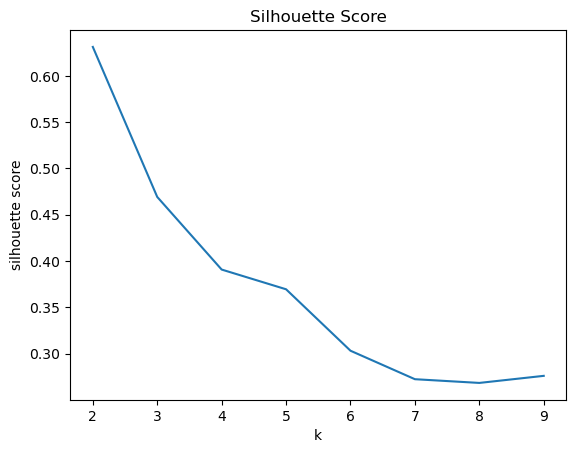

In [12]:
plt.plot(range(2,10),silhouette_score)
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.title('Silhouette Score')
plt.show()


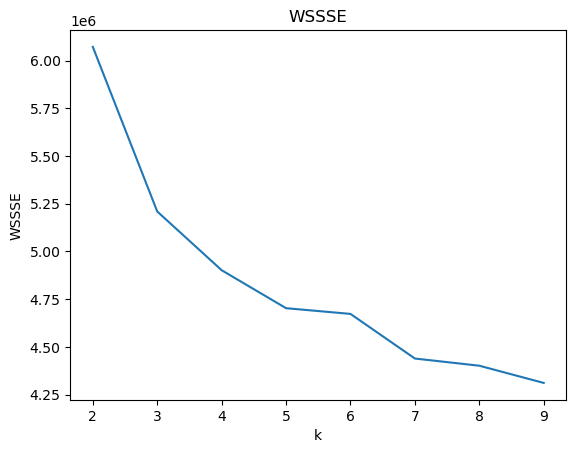

In [13]:
plt.plot(range(2,10),wssse)
plt.xlabel('k')
plt.ylabel('WSSSE')
plt.title('WSSSE')
plt.show()

In [20]:
kmeans=KMeans(featuresCol='features', k=3, predictionCol="cluster")
model=kmeans.fit(vectorized_embed_destinations)
predictions=model.transform(vectorized_embed_destinations)
predictions.groupBy("cluster").count().orderBy("cluster").show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0|33367|
|      1| 8019|
|      2|20720|
+-------+-----+



In [15]:
predictions.show()

+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------

In [ ]:
cluster_mapping = predictions.select(
    "srch_destination_id",
    F.col("cluster")
)

destinations = destinations.join(
    cluster_mapping,
    on="srch_destination_id",
    how="left"
)


In [22]:
destinations.show()

+-------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+----

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


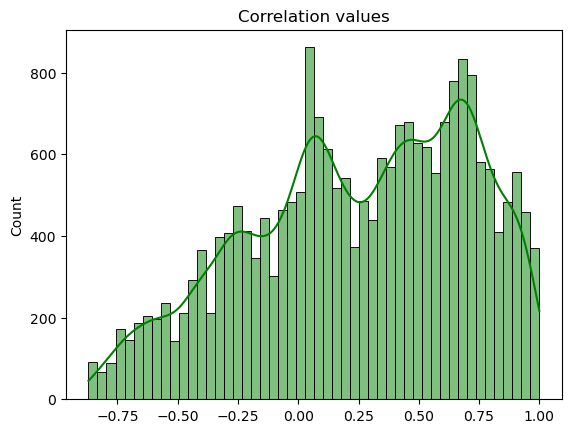

In [ ]:
from pyspark.ml.stat import Correlation

correlation_matrix = Correlation.corr(vectorized_embed_destinations, 'features').collect()[0][0].toArray()

fig, ax = plt.subplots()
sns.histplot(correlation_matrix.flatten(), bins=50, color='g', kde=True, ax=ax)
ax.set_title('Correlation values')
fig.savefig('CorrelationHist.png', bbox_inches='tight')
plt.show()

In [ ]:
hotel_rec_train.describe().show()

+-------+-----------------+------------------+---------------------+--------------------+------------------+-------------------------+-----------------+-------------------+-------------------+------------------+------------------+------------------+-------------------+-------------------+------------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|summary|        site_name|    posa_continent|user_location_country|user_location_region|user_location_city|orig_destination_distance|          user_id|          is_mobile|         is_package|           channel|   srch_adults_cnt| srch_children_cnt|        srch_rm_cnt|srch_destination_id|srch_destination_type_id|         is_booking|               cnt|   hotel_continent|     hotel_country|      hotel_market|     hotel_cluster|
+-------+-----------------+------------------+---------------------+--------------------+------------------+-------------------------+------

In [ ]:
hotel_rec_train.printSchema()

root
 |-- date_time: timestamp (nullable = true)
 |-- site_name: integer (nullable = true)
 |-- posa_continent: integer (nullable = true)
 |-- user_location_country: integer (nullable = true)
 |-- user_location_region: integer (nullable = true)
 |-- user_location_city: integer (nullable = true)
 |-- orig_destination_distance: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_mobile: integer (nullable = true)
 |-- is_package: integer (nullable = true)
 |-- channel: integer (nullable = true)
 |-- srch_ci: date (nullable = true)
 |-- srch_co: date (nullable = true)
 |-- srch_adults_cnt: integer (nullable = true)
 |-- srch_children_cnt: integer (nullable = true)
 |-- srch_rm_cnt: integer (nullable = true)
 |-- srch_destination_id: integer (nullable = true)
 |-- srch_destination_type_id: integer (nullable = true)
 |-- is_booking: integer (nullable = true)
 |-- cnt: integer (nullable = true)
 |-- hotel_continent: integer (nullable = true)
 |-- hotel_country: integer (n

In [ ]:
exprs = []

for field in hotel_rec_train.schema.fields:
    c = field.name

    if isinstance(field.dataType, (FloatType, DoubleType)):
        expr = F.sum(
            F.when(
                F.col(c).isNull() | F.isnan(F.col(c)),
                1
            ).otherwise(0)
        ).alias(c)
    else:
        expr = F.sum(
            F.when(
                F.col(c).isNull(),
                1
            ).otherwise(0)
        ).alias(c)

    exprs.append(expr)


result = hotel_rec_train.agg(*exprs)
row = result.first()

for field in result.schema.fields:
    value = row[field.name]

    if value > 0:
        print(f"Column '{field.name}' has {value} missing values.")

Column 'orig_destination_distance' has 13525001 missing values.
Column 'srch_ci' has 47083 missing values.
Column 'srch_co' has 47084 missing values.


In [ ]:
hotel_rec_train_shape = (hotel_rec_train.count(), len(hotel_rec_train.columns))
hotel_rec_train_shape

(37670293, 24)

In [ ]:
hotel_rec_train.select('user_id').distinct().count()

1198786

In [ ]:
hotel_rec_train.groupBy('user_id').count().show()

+-------+-----+
|user_id|count|
+-------+-----+
|  42635|    9|
|  43852|   13|
|  44437|   25|
|  69478|   15|
|  83861|   24|
| 139379|    3|
| 142084|    9|
| 198591|   63|
| 211912|   10|
| 212727|    5|
| 221743|   62|
| 241533|    7|
| 242832|   26|
| 243856|    8|
| 280340|   15|
| 280383|   41|
| 281809|    3|
| 324400|   21|
| 326371|  106|
| 344048|    6|
+-------+-----+
only showing top 20 rows


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


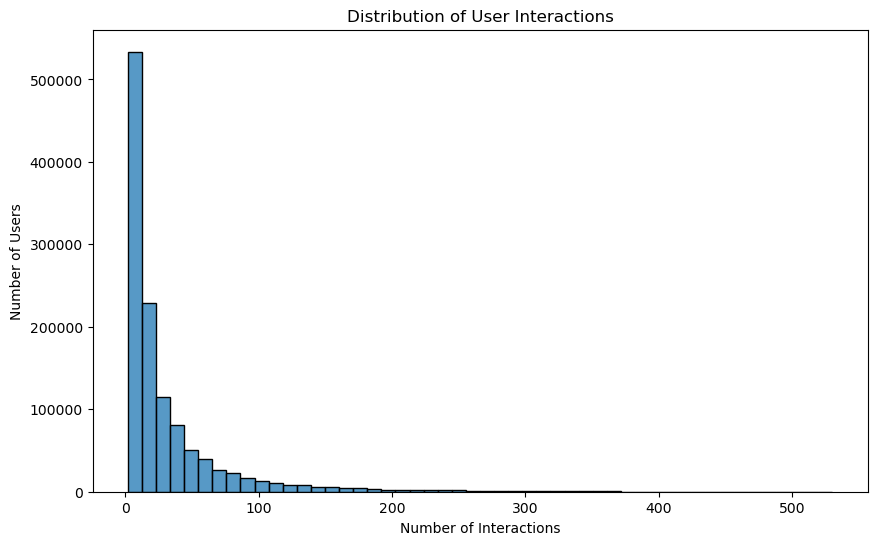

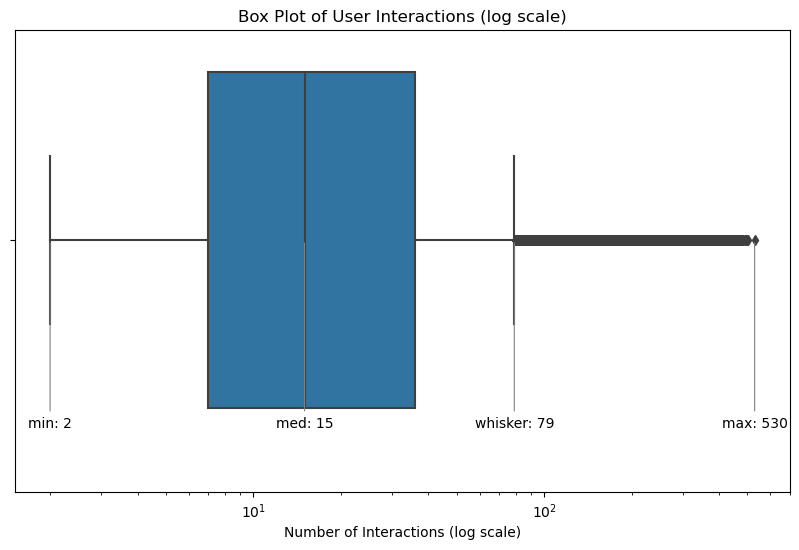

In [ ]:
user_interaction_counts = hotel_rec_train.groupBy('user_id').count().toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(user_interaction_counts['count'], bins=50, kde=False)
plt.title('Distribution of User Interactions')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=user_interaction_counts['count'], ax=ax)
ax.set_xscale('log') 

stats = user_interaction_counts['count'].describe()

iqr = stats['75%'] - stats['25%']
upper_fence = stats['75%'] + 1.5 * iqr
whisker_max = user_interaction_counts.loc[
    user_interaction_counts['count'] <= upper_fence, 'count'
].max()

values = {
    'min': stats['min'],
    # 'q1': stats['25%'],
    'med': stats['50%'],
    # 'q3': stats['75%'],
    'whisker': whisker_max,
    'max': stats['max'],
}

for label, value in values.items():
    ax.annotate(
        f'{label}: {value:.0f}',
        xy=(value, 0),
        xytext=(value, -0.42),
        ha='center',
        va='top',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    )

ax.set_ylim(-0.6, 0.5)
ax.set_title('Box Plot of User Interactions (log scale)')
ax.set_xlabel('Number of Interactions (log scale)')
plt.show()

In [ ]:
hotel_rec_train.printSchema()

root
 |-- date_time: timestamp (nullable = true)
 |-- site_name: integer (nullable = true)
 |-- posa_continent: integer (nullable = true)
 |-- user_location_country: integer (nullable = true)
 |-- user_location_region: integer (nullable = true)
 |-- user_location_city: integer (nullable = true)
 |-- orig_destination_distance: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_mobile: integer (nullable = true)
 |-- is_package: integer (nullable = true)
 |-- channel: integer (nullable = true)
 |-- srch_ci: date (nullable = true)
 |-- srch_co: date (nullable = true)
 |-- srch_adults_cnt: integer (nullable = true)
 |-- srch_children_cnt: integer (nullable = true)
 |-- srch_rm_cnt: integer (nullable = true)
 |-- srch_destination_id: integer (nullable = true)
 |-- srch_destination_type_id: integer (nullable = true)
 |-- is_booking: integer (nullable = true)
 |-- cnt: integer (nullable = true)
 |-- hotel_continent: integer (nullable = true)
 |-- hotel_country: integer (n

In [ ]:
sites = hotel_rec_train.select('site_name').distinct().rdd.flatMap(lambda x: x).collect()
sites.sort()
print("Distinct site names:", sites)
print("Missing site names:", [s for s in range(sites[0], sites[-1]+1) if s not in sites])

Distinct site names: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 43, 44, 45, 46, 47, 48, 53]
Missing site names: [12, 39, 42, 49, 50, 51, 52]


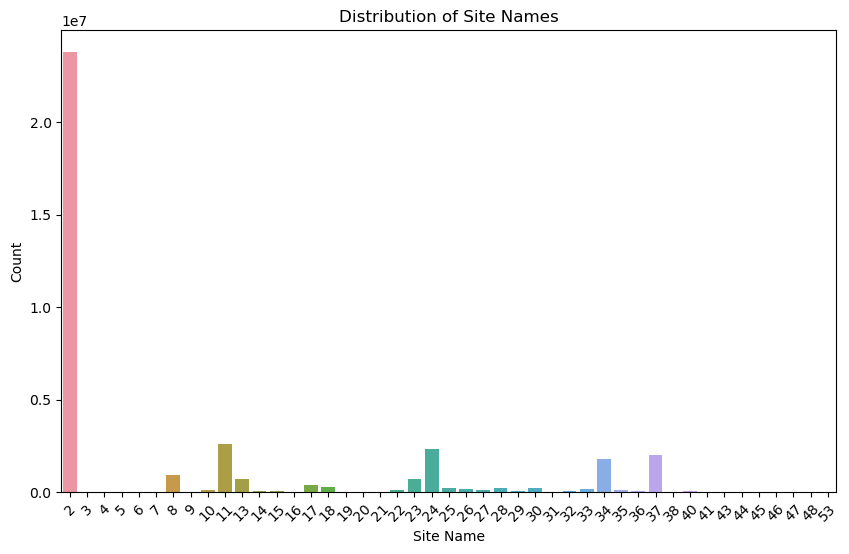

In [ ]:
sites_distribution = hotel_rec_train.groupBy('site_name').count().toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(x='site_name', y='count', data=sites_distribution)
plt.title('Distribution of Site Names')
plt.xlabel('Site Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Distinct posa_continent values: [0, 1, 2, 3, 4]


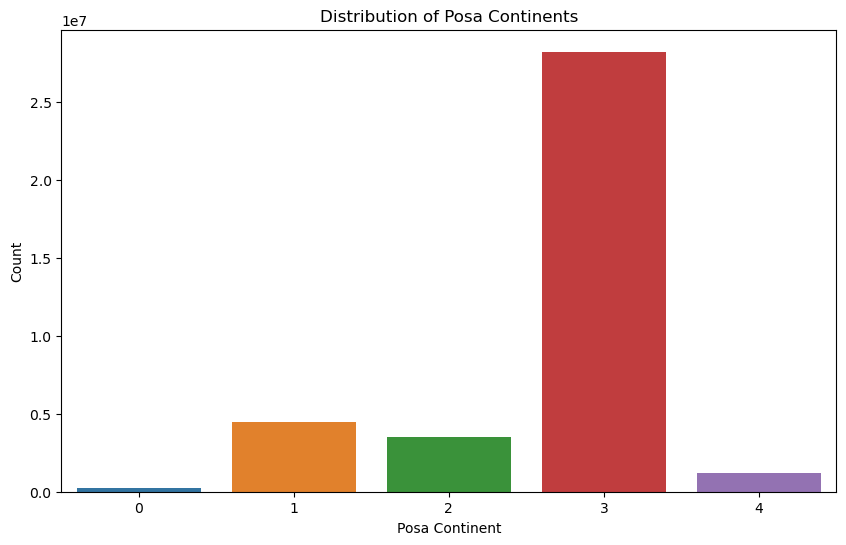

Distinct hotel_continent values: [0, 1, 2, 3, 4, 5, 6]


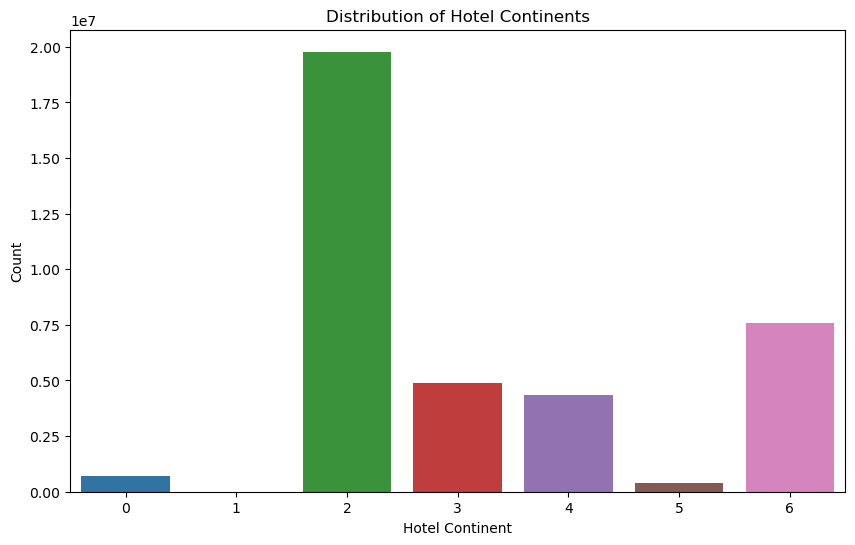

In [ ]:
posa_continents = hotel_rec_train.select('posa_continent').distinct().rdd.flatMap(lambda x: x).collect()
posa_continents.sort()
print("Distinct posa_continent values:", posa_continents)

continent_distribution = hotel_rec_train.groupBy('posa_continent').count().toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x='posa_continent', y='count', data=continent_distribution)
plt.title('Distribution of Posa Continents')
plt.xlabel('Posa Continent')
plt.ylabel('Count')
plt.show()

hotel_continents = hotel_rec_train.select('hotel_continent').distinct().rdd.flatMap(lambda x: x).collect()
hotel_continents.sort()
print("Distinct hotel_continent values:", hotel_continents)

hotel_continent_distribution = hotel_rec_train.groupBy('hotel_continent').count().toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x='hotel_continent', y='count', data=hotel_continent_distribution)
plt.title('Distribution of Hotel Continents')
plt.xlabel('Hotel Continent')
plt.ylabel('Count')
plt.show()

In [ ]:
user_location_countries = hotel_rec_train.select('user_location_country').distinct().rdd.flatMap(lambda x: x).collect()
user_location_countries.sort()
print("min:", user_location_countries[0])
print("max:", user_location_countries[-1])
print("count: ", len(user_location_countries))
print("missing: ", [c for c in range(user_location_countries[0], user_location_countries[-1]+1) if c not in user_location_countries])

hotel_location_countries = hotel_rec_train.select('hotel_country').distinct().rdd.flatMap(lambda x: x).collect()
hotel_location_countries.sort()
print("min:", hotel_location_countries[0])
print("max:", hotel_location_countries[-1])
print("count: ", len(hotel_location_countries))
print("missing: ", [c for c in range(hotel_location_countries[0], hotel_location_countries[-1]+1) if c not in hotel_location_countries])

min: 0
max: 239
count:  237
missing:  [2, 14, 177]


min: 0
max: 212
count:  213
missing:  []


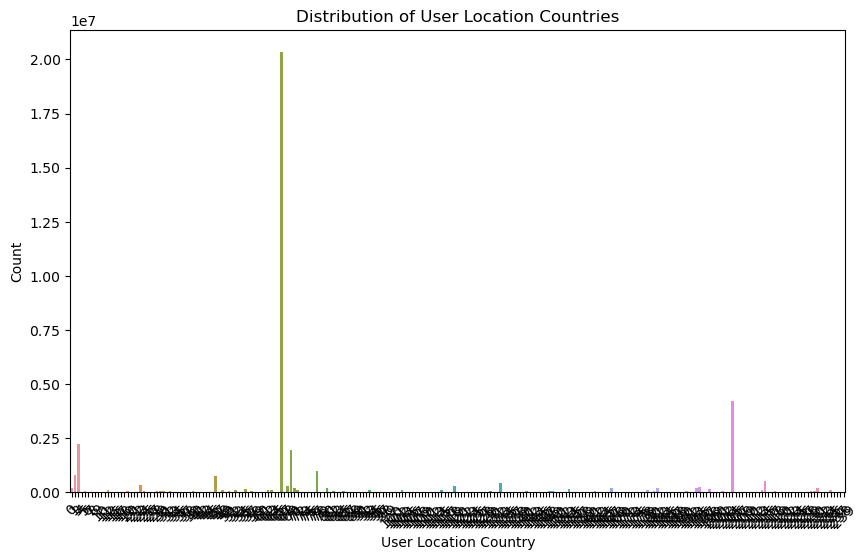

In [ ]:
user_country_distribution = hotel_rec_train.groupBy('user_location_country').count().toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x='user_location_country', y='count', data=user_country_distribution)
plt.title('Distribution of User Location Countries')
plt.xlabel('User Location Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


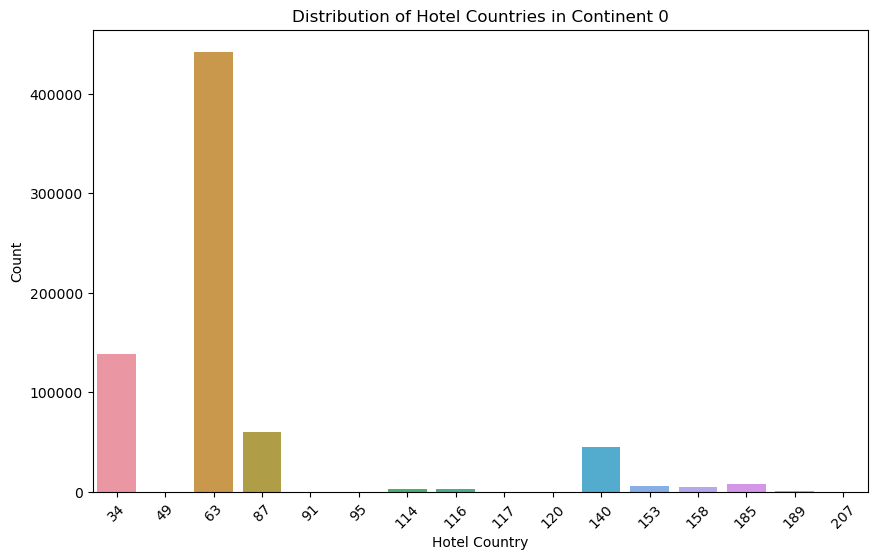

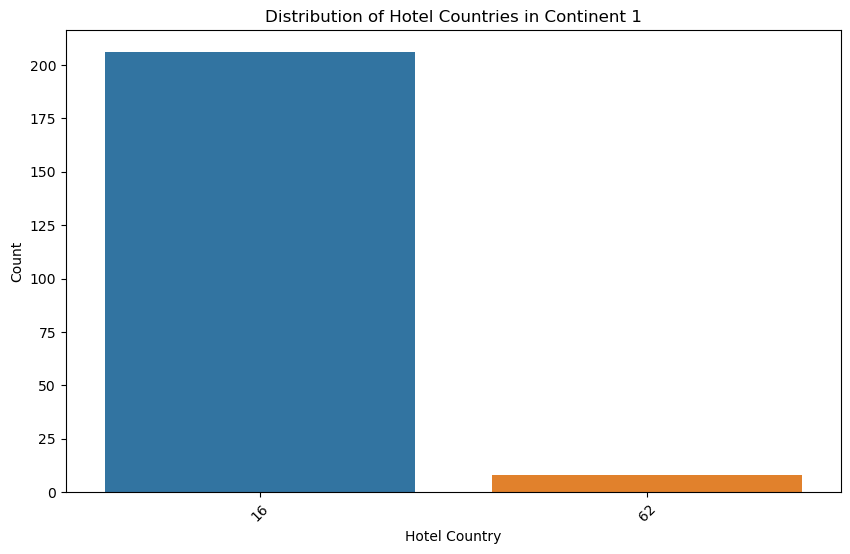

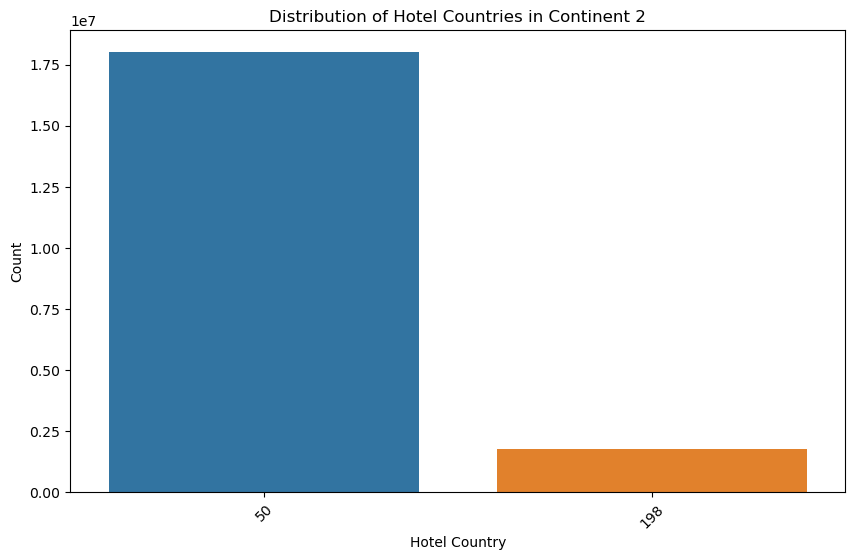

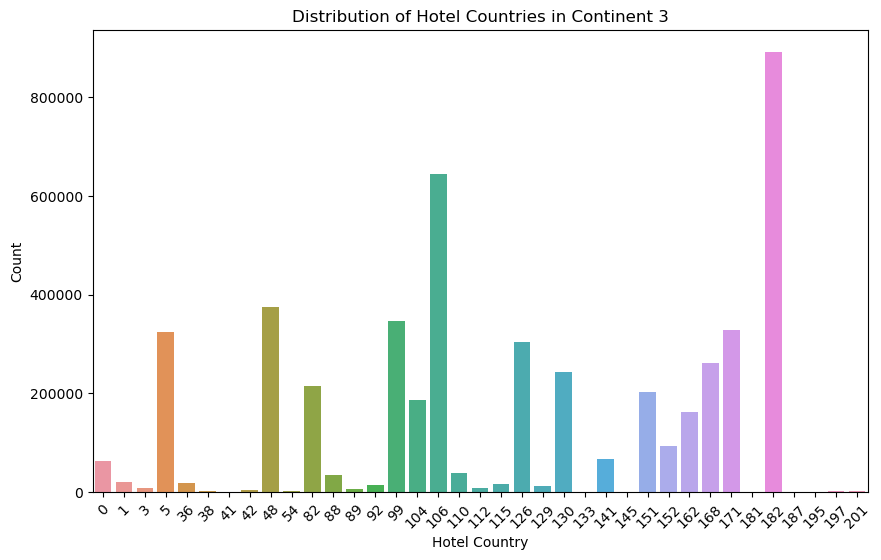

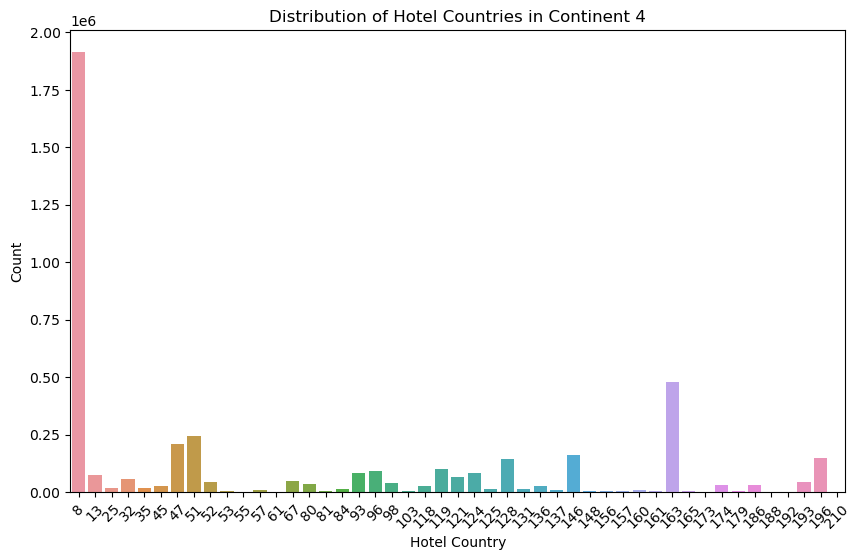

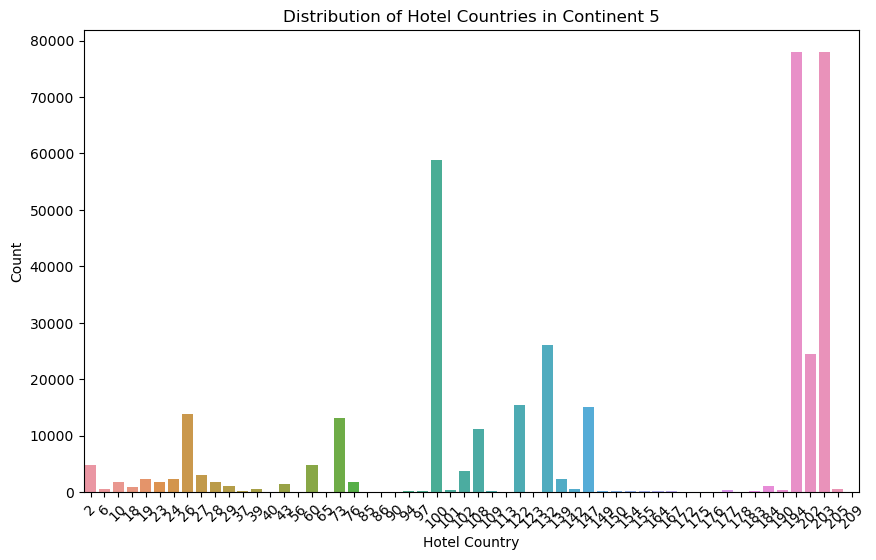

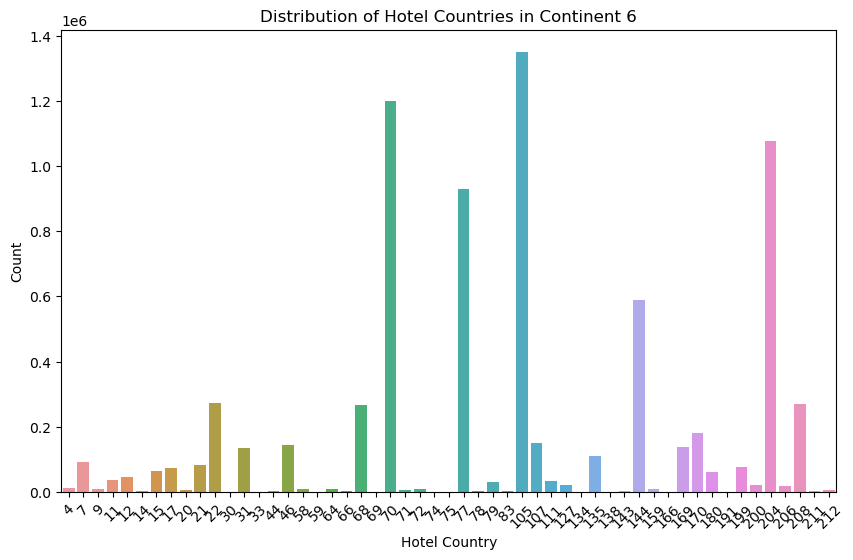

In [ ]:
# Hotel contry distribution on hotel continent
for continent in hotel_continents:
    continent_hotels = hotel_rec_train.filter(hotel_rec_train['hotel_continent'] == continent)
    continent_hotel_distribution = continent_hotels.groupBy('hotel_country').count().sort('count', ascending=False).toPandas()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='hotel_country', y='count', data=continent_hotel_distribution)
    plt.title(f'Distribution of Hotel Countries in Continent {continent}')
    plt.xlabel('Hotel Country')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
most_common_user_location_country = user_country_distribution.sort_values(by='count', ascending=False).head(1)
print(most_common_user_location_country['user_location_country'].iloc[0], "with count:", most_common_user_location_country['count'].iloc[0])
print("Percentage of total:", (most_common_user_location_country['count'].iloc[0] / hotel_rec_train_shape[0]) * 100, "%")

hotel_country_distribution = hotel_rec_train.groupBy('hotel_country').count().toPandas()
most_common_hotel_country = hotel_country_distribution.sort_values(by='count', ascending=False).head(1)
print(most_common_hotel_country['hotel_country'].iloc[0], "with count:", most_common_hotel_country['count'].iloc[0])
print("Percentage of total:", (most_common_hotel_country['count'].iloc[0] / hotel_rec_train_shape[0]) * 100, "%")

66 with count: 20346844
Percentage of total: 54.01296984868156 %


50 with count: 18015006
Percentage of total: 47.82284544481775 %


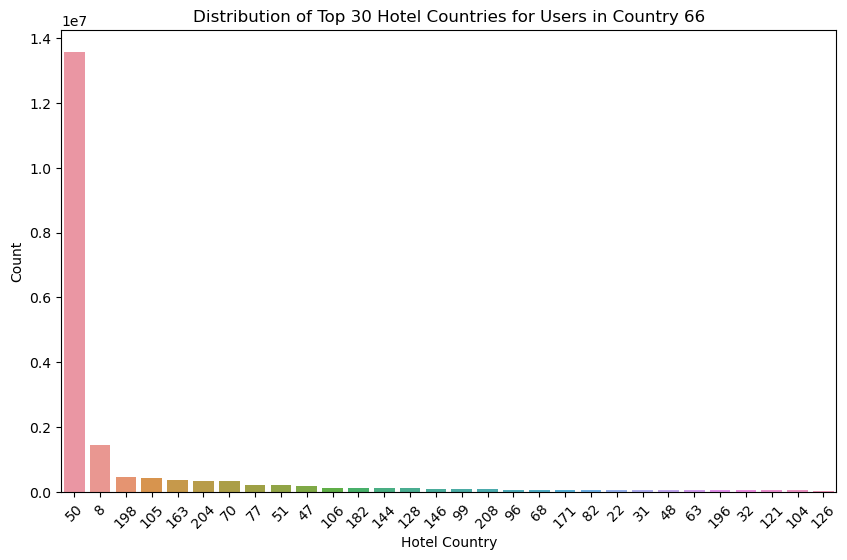

In [ ]:
# Top 30 Hotel Search Distribution for Users in Country 66
country_66_users = hotel_rec_train[hotel_rec_train['user_location_country'] == 66]
country_66_hotel_distribution = country_66_users.groupBy('hotel_country').count().sort('count', ascending=False).toPandas().head(30)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='hotel_country',
    y='count',
    data=country_66_hotel_distribution,
    order=country_66_hotel_distribution['hotel_country'],
)
plt.title('Distribution of Top 30 Hotel Countries for Users in Country 66')
plt.xlabel('Hotel Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

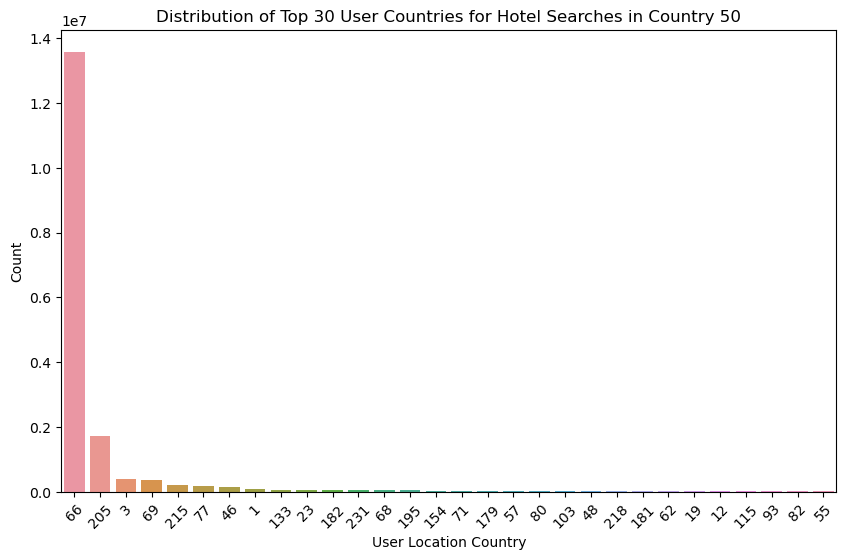

In [ ]:
# Top 30 User Contries Distribution search for Hotel in Country 50
country_50_hotels = hotel_rec_train[hotel_rec_train['hotel_country'] == 50]
country_50_user_distribution = country_50_hotels.groupBy('user_location_country').count().sort('count', ascending=False).toPandas().head(30)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='user_location_country',
    y='count',
    data=country_50_user_distribution,
    order=country_50_user_distribution['user_location_country'],
)
plt.title('Distribution of Top 30 User Countries for Hotel Searches in Country 50')
plt.xlabel('User Location Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


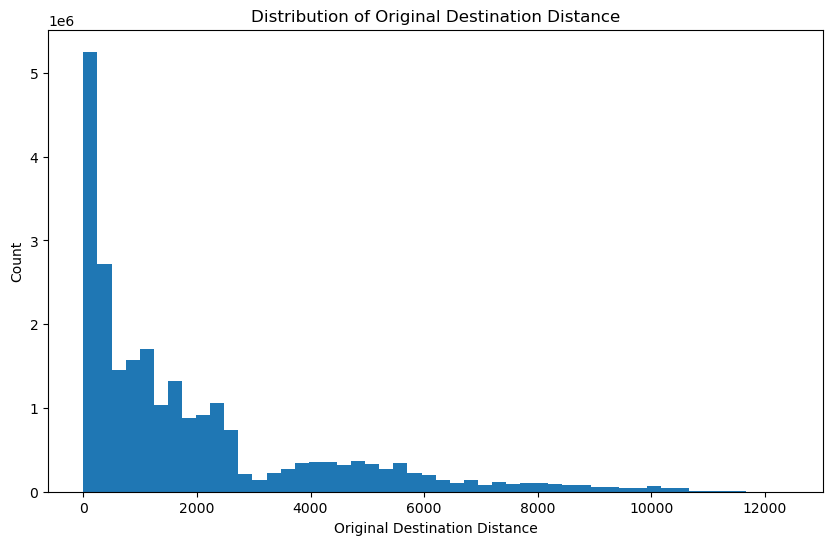

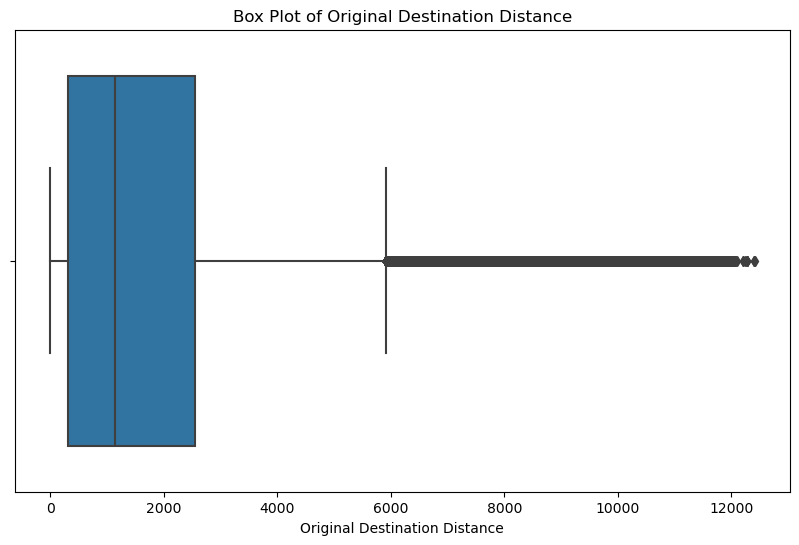

In [ ]:
orig_dest_distance = hotel_rec_train.select('orig_destination_distance').filter(F.col('orig_destination_distance').isNotNull()).toPandas()
plt.figure(figsize=(10, 6))
plt.hist(orig_dest_distance['orig_destination_distance'], bins=50)
plt.title('Distribution of Original Destination Distance')
plt.xlabel('Original Destination Distance')
plt.ylabel('Count')
plt.show()

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=orig_dest_distance['orig_destination_distance'])
plt.title('Box Plot of Original Destination Distance')
plt.xlabel('Original Destination Distance')
plt.show()

In [ ]:
hotel_rec_train.printSchema()

root
 |-- date_time: timestamp (nullable = true)
 |-- site_name: integer (nullable = true)
 |-- posa_continent: integer (nullable = true)
 |-- user_location_country: integer (nullable = true)
 |-- user_location_region: integer (nullable = true)
 |-- user_location_city: integer (nullable = true)
 |-- orig_destination_distance: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_mobile: integer (nullable = true)
 |-- is_package: integer (nullable = true)
 |-- channel: integer (nullable = true)
 |-- srch_ci: date (nullable = true)
 |-- srch_co: date (nullable = true)
 |-- srch_adults_cnt: integer (nullable = true)
 |-- srch_children_cnt: integer (nullable = true)
 |-- srch_rm_cnt: integer (nullable = true)
 |-- srch_destination_id: integer (nullable = true)
 |-- srch_destination_type_id: integer (nullable = true)
 |-- is_booking: integer (nullable = true)
 |-- cnt: integer (nullable = true)
 |-- hotel_continent: integer (nullable = true)
 |-- hotel_country: integer (n

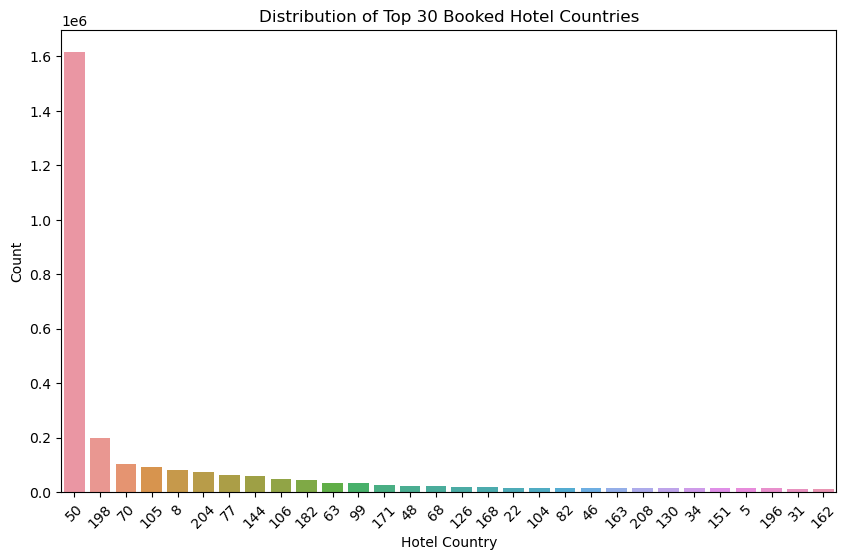

In [ ]:
booked_hotels = hotel_rec_train.filter(hotel_rec_train['is_booking'] == 1)

booked_hotels_distribution = booked_hotels.groupBy('hotel_country').count().sort('count', ascending=False).toPandas().head(30)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='hotel_country',
    y='count',
    data=booked_hotels_distribution,
    order=booked_hotels_distribution['hotel_country'],
)
plt.title('Distribution of Top 30 Booked Hotel Countries')
plt.xlabel('Hotel Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2013-01'),
  Text(1, 0, '2013-02'),
  Text(2, 0, '2013-03'),
  Text(3, 0, '2013-04'),
  Text(4, 0, '2013-05'),
  Text(5, 0, '2013-06'),
  Text(6, 0, '2013-07'),
  Text(7, 0, '2013-08'),
  Text(8, 0, '2013-09'),
  Text(9, 0, '2013-10'),
  Text(10, 0, '2013-11'),
  Text(11, 0, '2013-12'),
  Text(12, 0, '2014-01'),
  Text(13, 0, '2014-02'),
  Text(14, 0, '2014-03'),
  Text(15, 0, '2014-04'),
  Text(16, 0, '2014-05'),
  Text(17, 0, '2014-06'),
  Text(18, 0, '2014-07'),
  Text(19, 0, '2014-08'),
  Text(20, 0, '2014-09'),
  Text(21, 0, '2014-10'),
  Text(22, 0, '2014-11'),
  Text(23, 0, '2014-12')])

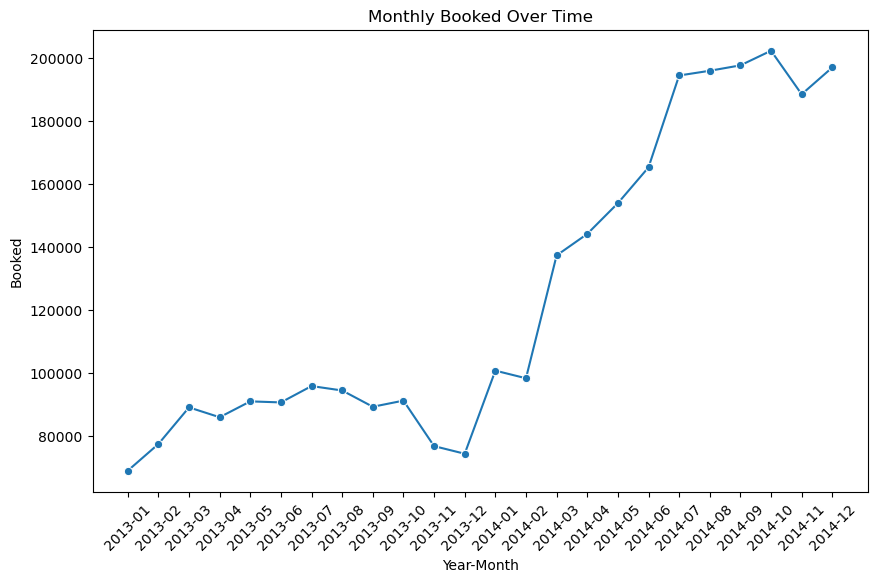

In [ ]:
monthly_booked = hotel_rec_train.withColumn('year_month', F.date_format(F.col('date_time'), 'yyyy-MM')).groupBy('year_month').agg(
    F.sum(F.col('is_booking')).alias('booked')
).sort('year_month').toPandas()

plt.figure(figsize=(10, 6))
sns.lineplot(x='year_month', y='booked', data=monthly_booked, marker='o')
plt.title('Monthly Booked Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Booked')
plt.xticks(rotation=45)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, '2013-01'),
  Text(1, 0, '2013-02'),
  Text(2, 0, '2013-03'),
  Text(3, 0, '2013-04'),
  Text(4, 0, '2013-05'),
  Text(5, 0, '2013-06'),
  Text(6, 0, '2013-07'),
  Text(7, 0, '2013-08'),
  Text(8, 0, '2013-09'),
  Text(9, 0, '2013-10'),
  Text(10, 0, '2013-11'),
  Text(11, 0, '2013-12'),
  Text(12, 0, '2014-01'),
  Text(13, 0, '2014-02'),
  Text(14, 0, '2014-03'),
  Text(15, 0, '2014-04'),
  Text(16, 0, '2014-05'),
  Text(17, 0, '2014-06'),
  Text(18, 0, '2014-07'),
  Text(19, 0, '2014-08'),
  Text(20, 0, '2014-09'),
  Text(21, 0, '2014-10'),
  Text(22, 0, '2014-11'),
  Text(23, 0, '2014-12')])

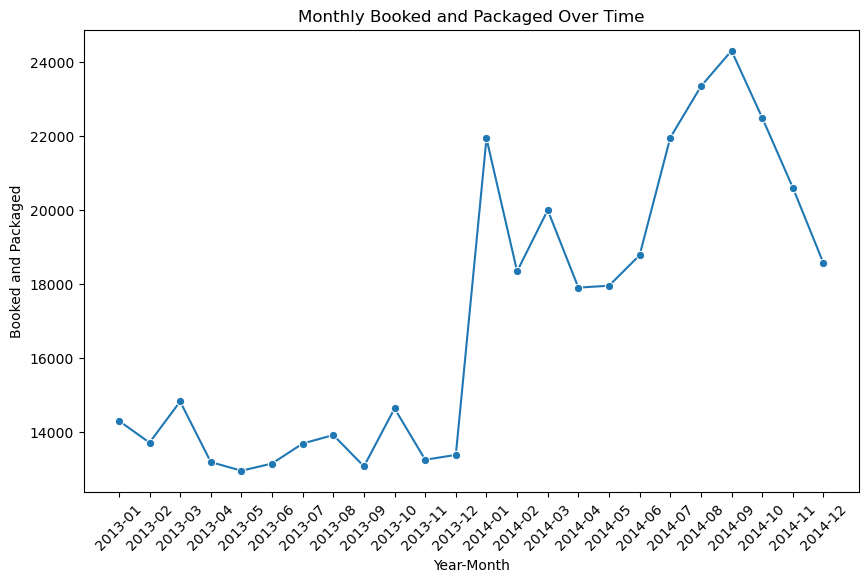

In [ ]:
monthly_booked_and_packaged = hotel_rec_train.withColumn('year_month', F.date_format(F.col('date_time'), 'yyyy-MM')).groupBy('year_month').agg(
    F.sum(
        F.when((F.col('is_package') == 1) & (F.col('is_booking') == 1), 1).otherwise(0)
    ).alias('booked_and_packaged'),
).sort('year_month').toPandas()

plt.figure(figsize=(10, 6))
sns.lineplot(x='year_month', y='booked_and_packaged', data=monthly_booked_and_packaged, marker='o')
plt.title('Monthly Booked and Packaged Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Booked and Packaged')
plt.xticks(rotation=45)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


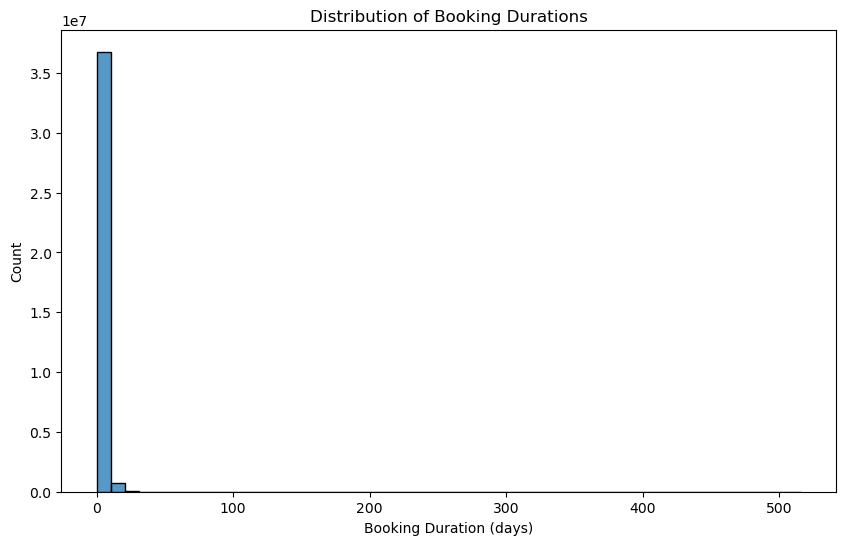

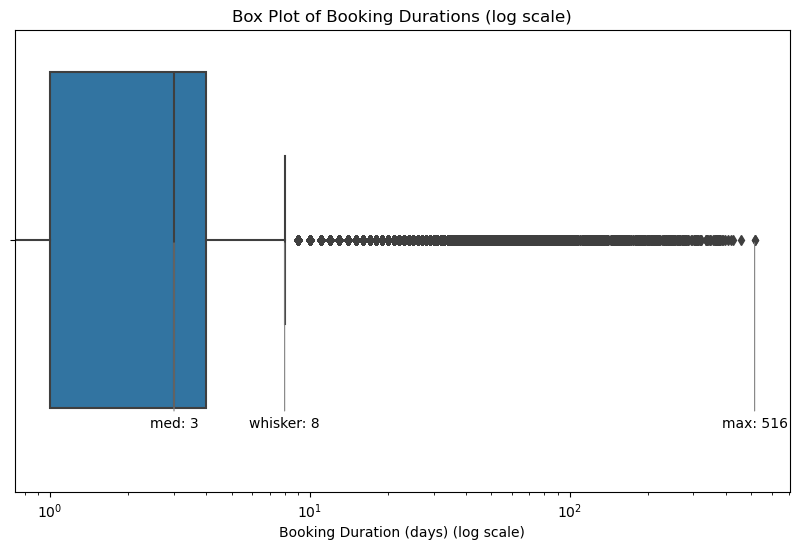

In [ ]:
book_durations = hotel_rec_train.select('srch_ci', 'srch_co').filter(
    (F.col('srch_ci').isNotNull()) & (F.col('srch_co').isNotNull())
).withColumn(
    'duration', F.datediff(F.col('srch_co'), F.col('srch_ci'))
).filter(F.col('duration') >= 0).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(book_durations['duration'], bins=50, kde=False)
plt.title('Distribution of Booking Durations')
plt.xlabel('Booking Duration (days)')
plt.ylabel('Count')
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=book_durations['duration'], ax=ax)
ax.set_xscale('log') 

stats = book_durations['duration'].describe()

iqr = stats['75%'] - stats['25%']
upper_fence = stats['75%'] + 1.5 * iqr
whisker_max = book_durations.loc[
    book_durations['duration'] <= upper_fence, 'duration'
].max()

values = {
    'min': stats['min'],
    # 'q1': stats['25%'],
    'med': stats['50%'],
    # 'q3': stats['75%'],
    'whisker': whisker_max,
    'max': stats['max'],
}

for label, value in values.items():
    ax.annotate(
        f'{label}: {value:.0f}',
        xy=(value, 0),
        xytext=(value, -0.42),
        ha='center',
        va='top',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    )

ax.set_ylim(-0.6, 0.5)
ax.set_title('Box Plot of Booking Durations (log scale)')
ax.set_xlabel('Booking Duration (days) (log scale)')
plt.show()

In [ ]:
# data range
start = hotel_rec_train.agg(F.min('date_time')).first()[0]
end = hotel_rec_train.agg(F.max('date_time')).first()[0]
print(f"Data range: {start} to {end}")

first_checkin = hotel_rec_train.agg(F.min('srch_ci')).first()[0]
last_checkin = hotel_rec_train.agg(F.max('srch_ci')).first()[0]
print(f"Check-in date range: {first_checkin} to {last_checkin}")

first_checkout = hotel_rec_train.agg(F.min('srch_co')).first()[0]
last_checkout = hotel_rec_train.agg(F.max('srch_co')).first()[0]
print(f"Check-out date range: {first_checkout} to {last_checkout}")


Data range: 2013-01-07 00:00:02 to 2014-12-31 23:59:59


Check-in date range: 2012-02-15 to 2558-03-15
Check-out date range: 2012-09-04 to 2558-03-16


In [ ]:
hotel_rec_train.sort('srch_co', ascending=False).show(50)

+-------------------+---------+--------------+---------------------+--------------------+------------------+-------------------------+-------+---------+----------+-------+----------+----------+---------------+-----------------+-----------+-------------------+------------------------+----------+---+---------------+-------------+------------+-------------+
|          date_time|site_name|posa_continent|user_location_country|user_location_region|user_location_city|orig_destination_distance|user_id|is_mobile|is_package|channel|   srch_ci|   srch_co|srch_adults_cnt|srch_children_cnt|srch_rm_cnt|srch_destination_id|srch_destination_type_id|is_booking|cnt|hotel_continent|hotel_country|hotel_market|hotel_cluster|
+-------------------+---------+--------------+---------------------+--------------------+------------------+-------------------------+-------+---------+----------+-------+----------+----------+---------------+-----------------+-----------+-------------------+------------------------+--

In [ ]:
# check how many invalid booking durations (0 and negative values), how many missing column values in srch_ci or srch_co
invalid_durations = hotel_rec_train.withColumn('duration', F.datediff(F.col('srch_co'), F.col('srch_ci'))).filter(F.col('duration') <= 0)
invalid_durations_count = invalid_durations.count()
missing_srch_ci_co_count = hotel_rec_train.filter(F.col('srch_ci').isNull() | F.col('srch_co').isNull()).count()
print(f"Invalid booking durations (0 or negative): {invalid_durations_count}")
print(f"Missing srch_ci srch_co values: {missing_srch_ci_co_count}")

Invalid booking durations (0 or negative): 145602
Missing srch_ci srch_co values: 47088


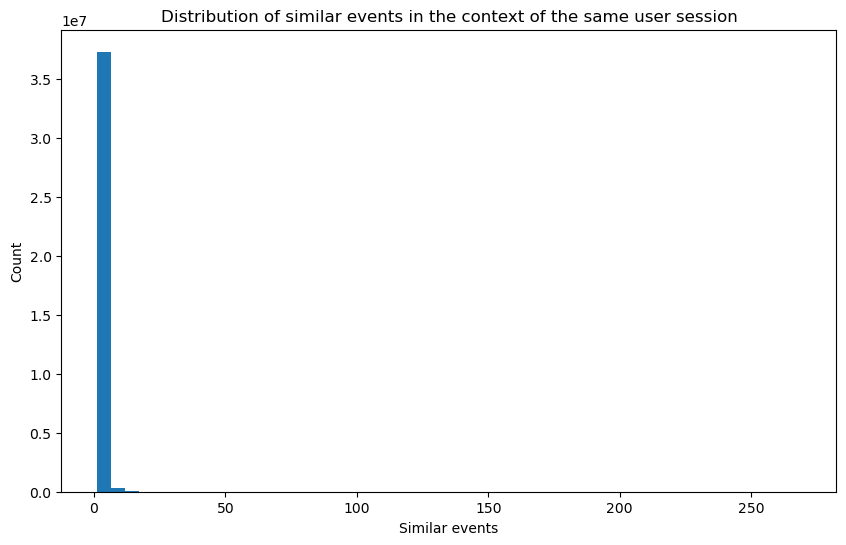

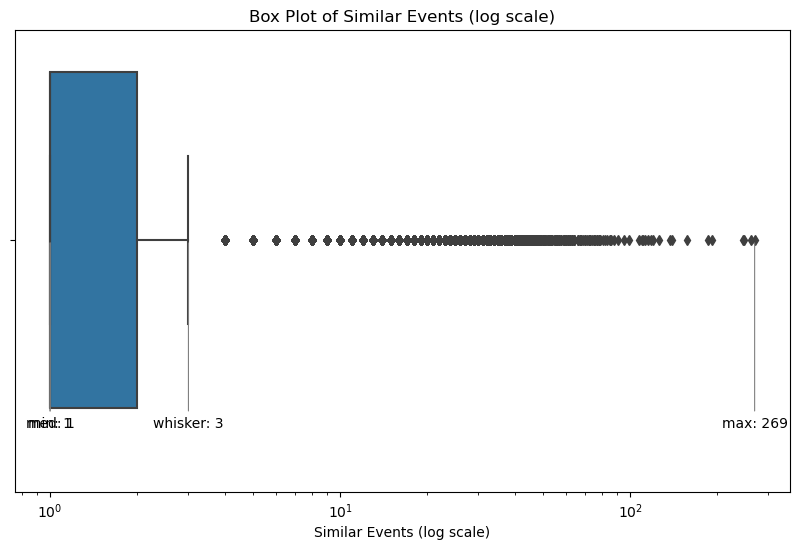

In [ ]:
cnt = hotel_rec_train.select('cnt').toPandas()
plt.figure(figsize=(10, 6))
plt.hist(cnt['cnt'], bins=50)
plt.title('Distribution of similar events in the context of the same user session')
plt.xlabel('Similar events')
plt.ylabel('Count')
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=cnt['cnt'], ax=ax)
ax.set_xscale('log') 

stats = cnt['cnt'].describe()

iqr = stats['75%'] - stats['25%']
upper_fence = stats['75%'] + 1.5 * iqr
whisker_max = cnt.loc[
    cnt['cnt'] <= upper_fence, 'cnt'
].max()

values = {
    'min': stats['min'],
    # 'q1': stats['25%'],
    'med': stats['50%'],
    # 'q3': stats['75%'],
    'whisker': whisker_max,
    'max': stats['max'],
}

for label, value in values.items():
    ax.annotate(
        f'{label}: {value:.0f}',
        xy=(value, 0),
        xytext=(value, -0.42),
        ha='center',
        va='top',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    )

ax.set_ylim(-0.6, 0.5)
ax.set_title('Box Plot of Similar Events (log scale)')
ax.set_xlabel('Similar Events (log scale)')
plt.show()

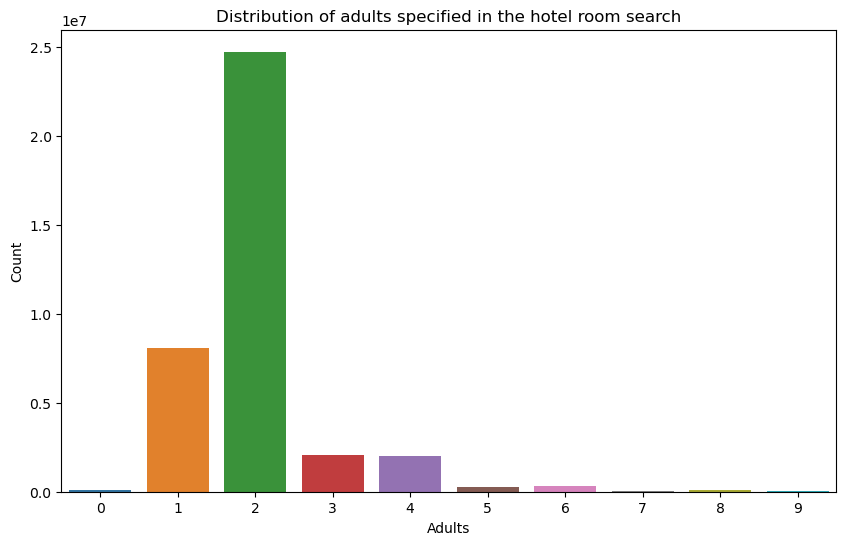

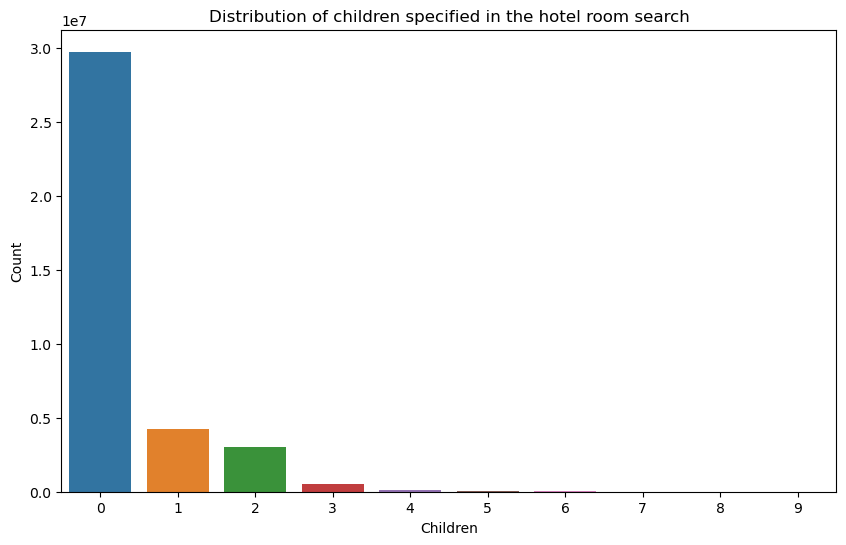

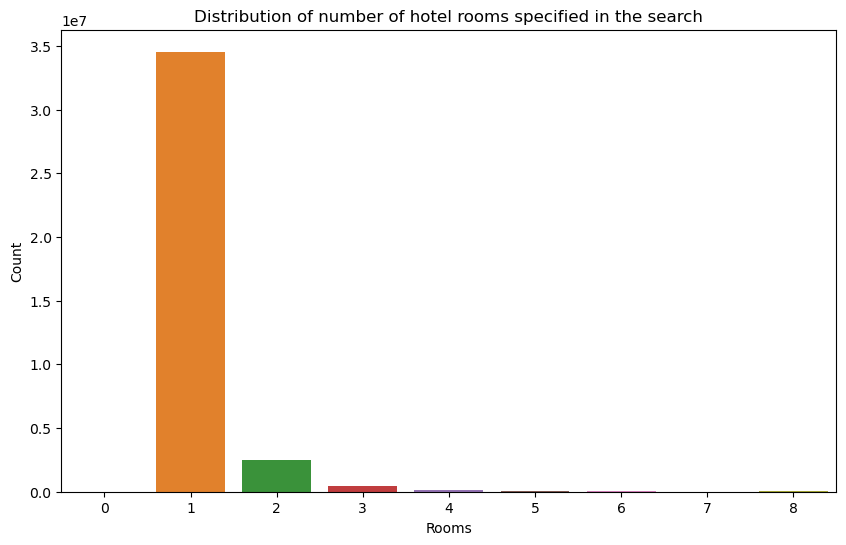

In [ ]:
adults_cnt = hotel_rec_train.select('srch_adults_cnt').toPandas()
plt.figure(figsize=(10, 6))
sns.countplot(x="srch_adults_cnt",data=adults_cnt, order=sorted(adults_cnt['srch_adults_cnt'].unique()))
plt.title('Distribution of adults specified in the hotel room search')
plt.xlabel('Adults')
plt.ylabel('Count')
plt.show()

children_cnt = hotel_rec_train.select('srch_children_cnt').toPandas()
plt.figure(figsize=(10, 6))
sns.countplot(x='srch_children_cnt',data=children_cnt, order=sorted(children_cnt['srch_children_cnt'].unique()))
plt.title('Distribution of children specified in the hotel room search')
plt.xlabel('Children')
plt.ylabel('Count')
plt.show()

room_cnt = hotel_rec_train.select('srch_rm_cnt').toPandas()
plt.figure(figsize=(10, 6))
sns.countplot(x='srch_rm_cnt',data=room_cnt, order=sorted(room_cnt['srch_rm_cnt'].unique()))
plt.title('Distribution of number of hotel rooms specified in the search')
plt.xlabel('Rooms')
plt.ylabel('Count')
plt.show()

26/09/17 15:17:13 WARN MemoryStore: Not enough space to cache rdd_1651_2 in memory! (computed 40.5 MiB so far)
26/09/17 15:17:13 WARN MemoryStore: Not enough space to cache rdd_1651_3 in memory! (computed 40.5 MiB so far)
26/09/17 15:17:13 WARN MemoryStore: Not enough space to cache rdd_1651_5 in memory! (computed 40.5 MiB so far)
26/09/17 15:17:13 WARN BlockManager: Persisting block rdd_1651_2 to disk instead.
26/09/17 15:17:13 WARN BlockManager: Persisting block rdd_1651_5 to disk instead.
26/09/17 15:17:13 WARN MemoryStore: Not enough space to cache rdd_1651_7 in memory! (computed 40.5 MiB so far)
26/09/17 15:17:13 WARN BlockManager: Persisting block rdd_1651_7 to disk instead.
26/09/17 15:17:13 WARN BlockManager: Persisting block rdd_1651_3 to disk instead.
26/09/17 15:17:14 WARN MemoryStore: Not enough space to cache rdd_1651_6 in memory! (computed 40.5 MiB so far)
26/09/17 15:17:14 WARN BlockManager: Persisting block rdd_1651_6 to disk instead.
26/09/17 15:17:14 WARN MemoryStore:

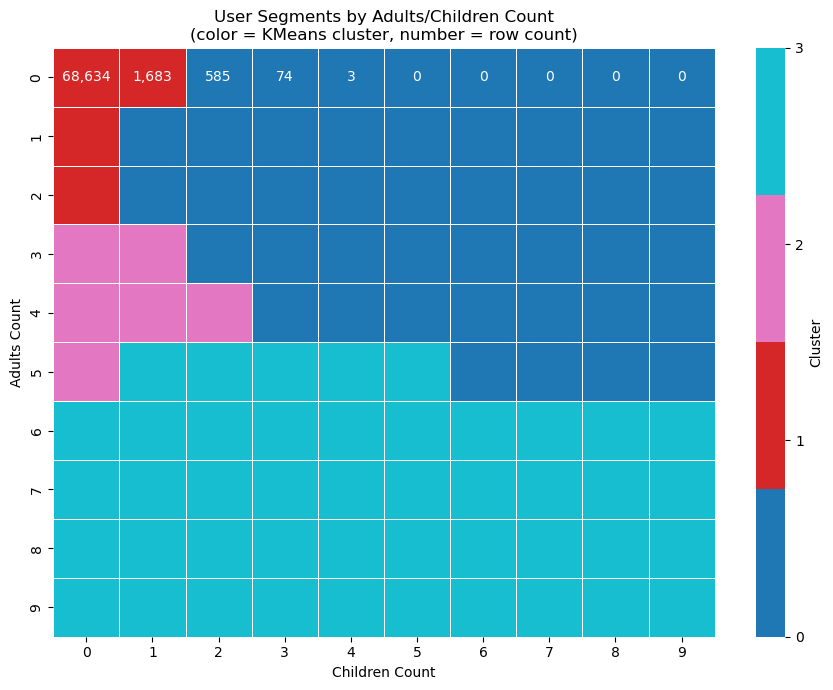

Cluster centers (adults, children):
0: [1.905011   1.61725495]
1: [1.72772444e+00 6.39839364e-05]
2: [3.58709372 0.26626267]
3: [6.33415247 0.70068123]


In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

vec_assembler = VectorAssembler(inputCols=['srch_adults_cnt', 'srch_children_cnt'], outputCol='features')
adults_children_vec = vec_assembler.transform(
    hotel_rec_train.select('srch_adults_cnt', 'srch_children_cnt')
)

# Cluster users by household composition (adults, children); k is adjustable
k = 4
kmeans = KMeans(featuresCol='features', k=k, seed=42)
model = kmeans.fit(adults_children_vec)

# Predict a cluster for every possible (adults, children) combo 0-9 so the grid has no gaps
grid_points = spark.createDataFrame(
    [(a, c) for a in range(10) for c in range(10)],
    ['srch_adults_cnt', 'srch_children_cnt'],
)
grid_predictions = model.transform(vec_assembler.transform(grid_points)) \
    .select('srch_adults_cnt', 'srch_children_cnt', 'prediction') \
    .toPandas()
cluster_grid = grid_predictions.pivot(index='srch_adults_cnt', columns='srch_children_cnt', values='prediction')

count_grid = hotel_rec_train.groupBy('srch_adults_cnt', 'srch_children_cnt').count().toPandas()
count_grid = (
    count_grid.pivot(index='srch_adults_cnt', columns='srch_children_cnt', values='count')
    .reindex(index=range(10), columns=range(10))
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(9, 7))
cmap = plt.get_cmap('tab10', k)
sns.heatmap(
    cluster_grid,
    annot=count_grid.map(lambda v: f'{v:,}'),
    fmt='',
    cmap=cmap,
    cbar_kws={'label': 'Cluster', 'ticks': range(k)},
    linewidths=0.5,
    linecolor='white',
)
plt.title('User Segments by Adults/Children Count\n(color = KMeans cluster, number = row count)')
plt.xlabel('Children Count')
plt.ylabel('Adults Count')
plt.tight_layout()
plt.show()

print('Cluster centers (adults, children):')
for i, center in enumerate(model.clusterCenters()):
    print(f'{i}: {center}')

In [26]:
usecols = ["srch_destination_id", "srch_adults_cnt", "srch_rm_cnt", "srch_children_cnt", "cnt", "is_package", "is_booking", "srch_ci", "srch_co", "orig_destination_distance"]
hotel_rec_with_cluster = hotel_rec_train.select(*usecols).join(
    cluster_mapping, on='srch_destination_id', how='left'
).withColumn(
    'duration', F.datediff(F.col('srch_co'), F.col('srch_ci'))
).filter(F.col('duration') >= 0)

cluster_avg = hotel_rec_with_cluster.groupBy('cluster').agg(
    F.avg('srch_adults_cnt').alias('avg_adults'),
    F.avg('srch_children_cnt').alias('avg_children'),
    F.avg('srch_rm_cnt').alias('avg_rooms'),
    F.avg('cnt').alias('avg_cnt'),
    F.avg('is_package').alias('package_rate'),
    F.avg('is_booking').alias('booking_rate'),
    F.avg('duration').alias('avg_duration'),
    F.avg('orig_destination_distance').alias('avg_distance'),
    F.count('*').alias('num_searches'),

).orderBy('cluster')

cluster_avg.show()

+-------+------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------+
|cluster|        avg_adults|       avg_children|         avg_rooms|           avg_cnt|       package_rate|       booking_rate|      avg_duration|      avg_distance|num_searches|
+-------+------------------+-------------------+------------------+------------------+-------------------+-------------------+------------------+------------------+------------+
|   NULL| 1.926727057991259| 0.2604061126731854|1.1007308109663612| 1.407569498983819|0.16181557664522395|0.07503552136977595|3.4616638988974886| 2157.944748975915|      166801|
|      0|1.9642967545527825|0.26232694730746053|1.1454615977586302|1.4214977617605398| 0.1273566078933158|0.11842272595653433|3.0006661892799285| 2527.947483251465|     2044464|
|      1| 2.058773469929678| 0.3677972416006942|1.1044473163795359|1.5049504722086289|  0.296666095660962|0.06

In [24]:
hotel_rec_train.printSchema()

root
 |-- date_time: timestamp (nullable = true)
 |-- site_name: integer (nullable = true)
 |-- posa_continent: integer (nullable = true)
 |-- user_location_country: integer (nullable = true)
 |-- user_location_region: integer (nullable = true)
 |-- user_location_city: integer (nullable = true)
 |-- orig_destination_distance: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- is_mobile: integer (nullable = true)
 |-- is_package: integer (nullable = true)
 |-- channel: integer (nullable = true)
 |-- srch_ci: date (nullable = true)
 |-- srch_co: date (nullable = true)
 |-- srch_adults_cnt: integer (nullable = true)
 |-- srch_children_cnt: integer (nullable = true)
 |-- srch_rm_cnt: integer (nullable = true)
 |-- srch_destination_id: integer (nullable = true)
 |-- srch_destination_type_id: integer (nullable = true)
 |-- is_booking: integer (nullable = true)
 |-- cnt: integer (nullable = true)
 |-- hotel_continent: integer (nullable = true)
 |-- hotel_country: integer (n

In [5]:
def plot_session_size_boxplot(series, title, xlabel):
    """Box plot (log scale) of a per-user session-size Series, annotated with min/med/whisker/max."""
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=series, ax=ax)
    ax.set_xscale('log')

    stats = series.describe()
    iqr = stats['75%'] - stats['25%']
    upper_fence = stats['75%'] + 1.5 * iqr
    whisker_max = series[series <= upper_fence].max()

    values = {
        'min': stats['min'],
        'med': stats['50%'],
        'whisker': whisker_max,
        'max': stats['max'],
    }
    for label, value in values.items():
        ax.annotate(
            f'{label}: {value:.0f}',
            xy=(value, 0),
            xytext=(value, -0.42),
            ha='center',
            va='top',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
        )

    ax.set_ylim(-0.6, 0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.show()

+-------+------------+-----------------+-------------------+
|user_id|session_date|events_in_session|bookings_in_session|
+-------+------------+-----------------+-------------------+
|      0|  2014-09-03|                1|                  0|
|      0|  2014-12-03|                4|                  0|
|      0|  2014-12-06|                1|                  0|
|      1|  2014-04-25|                4|                  0|
|      2|  2014-01-27|                9|                  0|
|      2|  2014-01-28|               10|                  0|
|      3|  2014-07-31|                1|                  0|
|      3|  2014-09-08|                2|                  0|
|      3|  2014-09-09|                1|                  0|
|      3|  2014-09-22|                2|                  0|
|      3|  2014-09-30|                1|                  0|
|      3|  2014-10-20|                1|                  0|
|      4|  2014-08-14|                1|                  0|
|      4|  2014-08-29|  

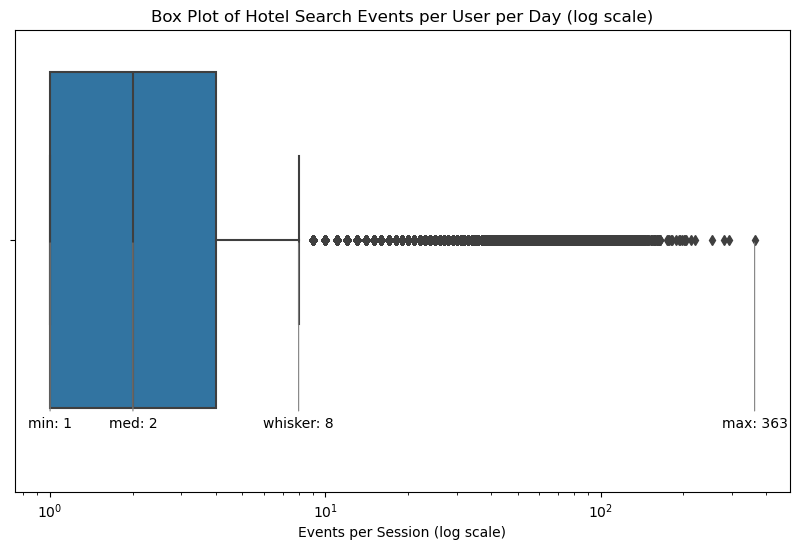

In [6]:
# Session = a user's activity on a single calendar day (no explicit session_id
# in this dataset, so date_time truncated to day is the natural proxy).
hotel_sessions = hotel_rec_train.withColumn(
    'session_date', F.to_date(F.col('date_time'))
).groupBy('user_id', 'session_date').agg(
    F.count('*').alias('events_in_session'),
    F.sum('is_booking').alias('bookings_in_session'),
).orderBy('user_id', 'session_date')

hotel_sessions.show(20)

hotel_sessions_pd = hotel_sessions.select('events_in_session').toPandas()['events_in_session']
plot_session_size_boxplot(
    hotel_sessions_pd,
    'Box Plot of Hotel Search Events per User per Day (log scale)',
    'Events per Session (log scale)',
)

[1101.179s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 29.0 (TID 349): Retried waiting for GCLocker too often allocating 4194306 words
[1101.304s][warning][gc,alloc] Executor task launch worker for task 6.0 in stage 29.0 (TID 354): Retried waiting for GCLocker too often allocating 4194306 words


26/09/18 10:01:53 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes) for 0 times, try again.
java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.unsafe.memory.HeapMemoryAllocator.allocate(HeapMemoryAllocator.java:72)
	at org.apache.spark.memory.TaskMemoryManager.allocatePage(TaskMemoryManager.java:398)
	at org.apache.spark.memory.TaskMemoryManager.allocatePage(TaskMemoryManager.java:359)
	at org.apache.spark.memory.MemoryConsumer.allocateArray(MemoryConsumer.java:97)
	at org.apache.spark.unsafe.map.BytesToBytesMap.allocate(BytesToBytesMap.java:868)
	at org.apache.spark.unsafe.map.BytesToBytesMap.growAndRehash(BytesToBytesMap.java:991)
	at org.apache.spark.unsafe.map.BytesToBytesMap$Location.append(BytesToBytesMap.java:817)
	at org.apache.spark.sql.execution.UnsafeFixedWidthAggregationMap.getAggregationBufferFromUnsafeRow(UnsafeFixedWidthAggregationMap.java:135)
	at org.apache.spark.sql.catalyst.expressions.GeneratedClass$GeneratedIteratorForCodegenStage3.ha

[1101.977s][warning][gc,alloc] Executor task launch worker for task 4.0 in stage 29.0 (TID 352): Retried waiting for GCLocker too often allocating 1048578 words
[1101.994s][warning][gc,alloc] Executor task launch worker for task 4.0 in stage 29.0 (TID 352): Retried waiting for GCLocker too often allocating 1048578 words


26/09/18 10:01:54 WARN TaskMemoryManager: Failed to allocate a page (8388608 bytes) for 0 times, try again.
java.lang.OutOfMemoryError: Java heap space
26/09/18 10:01:54 WARN TaskMemoryManager: Failed to allocate a page (8388608 bytes) for 1 times, try again.


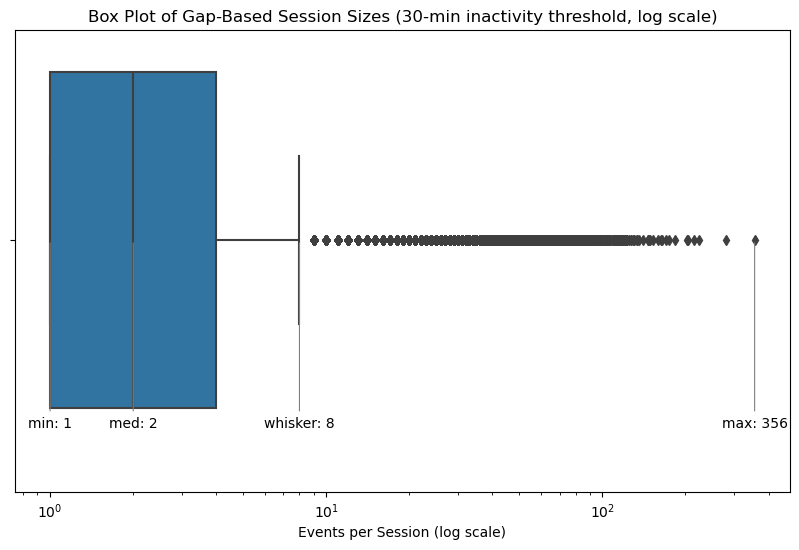

In [10]:
from pyspark.sql import Window

# Gap-based ("inactivity") session: a new session starts whenever the time since
# this user's previous event exceeds SESSION_GAP_MINUTES. Standard web-analytics
# definition (e.g. Google Analytics defaults to 30 min); adjust the threshold below.
SESSION_GAP_MINUTES = 30

# Only carry what the window actually needs through the shuffle/sort - selecting
# down from hotel_rec_train's 24 columns to 3 keeps this pass much lighter than
# working from the cached DataFrame directly.
user_events = hotel_rec_train.select('user_id', 'date_time', 'is_booking')

user_time_window = Window.partitionBy('user_id').orderBy('date_time')
cum_window = user_time_window.rowsBetween(Window.unboundedPreceding, Window.currentRow)

hotel_gap_sessions = user_events.withColumn(
    'prev_date_time', F.lag('date_time').over(user_time_window)
).withColumn(
    'gap_minutes', (F.col('date_time').cast('long') - F.col('prev_date_time').cast('long')) / 60.0
).withColumn(
    'new_session_flag',
    F.when(F.col('prev_date_time').isNull() | (F.col('gap_minutes') > SESSION_GAP_MINUTES), 1).otherwise(0)
).withColumn(
    'session_num', F.sum('new_session_flag').over(cum_window)
)

gap_session_sizes = hotel_gap_sessions.groupBy('user_id', 'session_num').agg(
    F.count('*').alias('events_in_session'),
    F.max('is_booking').alias('has_booking'),
)

gap_session_sizes_pd = gap_session_sizes.select('events_in_session').toPandas()['events_in_session']
plot_session_size_boxplot(
    gap_session_sizes_pd,
    f'Box Plot of Gap-Based Session Sizes ({SESSION_GAP_MINUTES}-min inactivity threshold, log scale)',
    'Events per Session (log scale)',
)

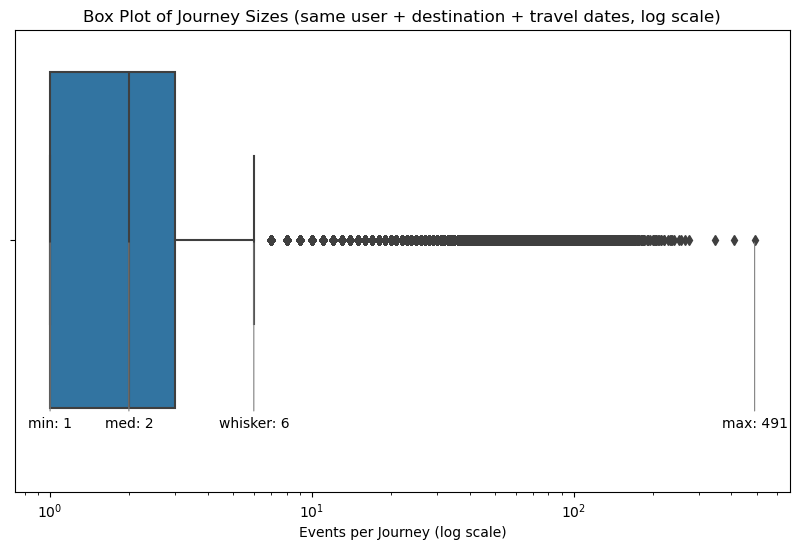

In [11]:
# Journey: same user researching the same trip (destination + exact travel dates),
# regardless of how many separate days/visits it took. Captures the "search day 1,
# search day 2, book day 3" case that a short inactivity gap would incorrectly split.
hotel_journeys = hotel_rec_train.groupBy(
    'user_id', 'srch_destination_id', 'srch_ci', 'srch_co'
).agg(
    F.count('*').alias('events_in_journey'),
    F.max('is_booking').alias('has_booking'),
)

journey_sizes_pd = hotel_journeys.select('events_in_journey').toPandas()['events_in_journey']
plot_session_size_boxplot(
    journey_sizes_pd,
    'Box Plot of Journey Sizes (same user + destination + travel dates, log scale)',
    'Events per Journey (log scale)',
)

In [12]:
# Quick comparison of how many groups each definition produces, and how many of
# those groups actually contain a booking (has_booking).
print(f"Raw rows:                         {hotel_rec_train.count():,}")
print(f"Calendar-day sessions:            {hotel_sessions.count():,}")
print(f"Gap-based sessions ({SESSION_GAP_MINUTES}-min):        {gap_session_sizes.count():,}")
print(f"Destination+date journeys:        {hotel_journeys.count():,}")
print()
print(f"Gap-based sessions with a booking:  {gap_session_sizes.filter(F.col('has_booking') == 1).count():,}")
print(f"Journeys with a booking:            {hotel_journeys.filter(F.col('has_booking') == 1).count():,}")

Raw rows:                         37,670,293


Calendar-day sessions:            9,923,555


[1209.821s][warning][gc,alloc] Executor task launch worker for task 8.0 in stage 42.0 (TID 483): Retried waiting for GCLocker too often allocating 4194306 words
[1209.837s][warning][gc,alloc] Executor task launch worker for task 8.0 in stage 42.0 (TID 483): Retried waiting for GCLocker too often allocating 4194306 words


26/09/18 10:03:42 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes) for 0 times, try again.
java.lang.OutOfMemoryError: Java heap space
26/09/18 10:03:42 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes) for 1 times, try again.


[1222.303s][warning][gc,alloc] Executor task launch worker for task 3.0 in stage 44.0 (TID 509): Retried waiting for GCLocker too often allocating 4194306 words
[1222.328s][warning][gc,alloc] Executor task launch worker for task 5.0 in stage 44.0 (TID 511): Retried waiting for GCLocker too often allocating 4194306 words


26/09/18 10:03:54 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes) for 0 times, try again.
java.lang.OutOfMemoryError: Java heap space
26/09/18 10:03:54 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes) for 0 times, try again.
java.lang.OutOfMemoryError: Java heap space


Gap-based sessions (30-min):        12,242,331


Destination+date journeys:        13,741,854



Gap-based sessions with a booking:  2,661,774


Journeys with a booking:            2,900,230


count    1.198786e+06
mean     2.503110e+00
std      4.804809e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      1.000000e+02
Name: num_bookings, dtype: float64

Share of users with 0 bookings: 32.10%


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


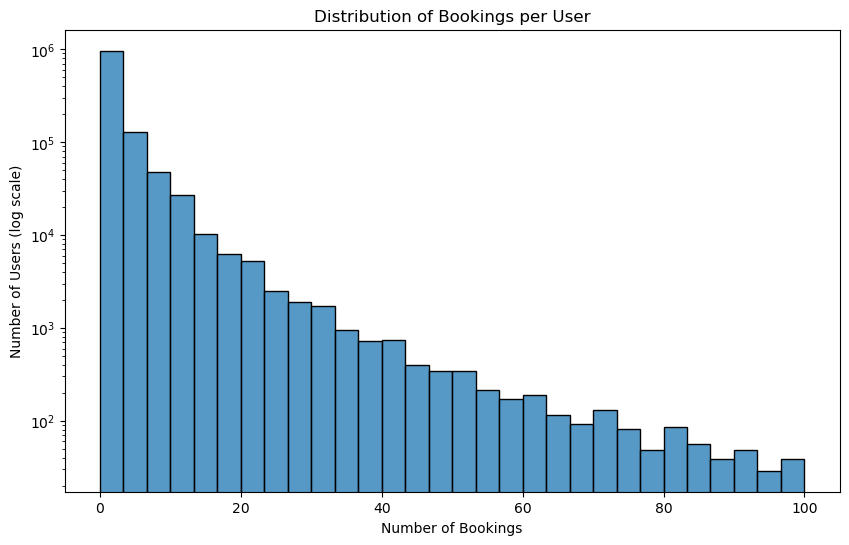

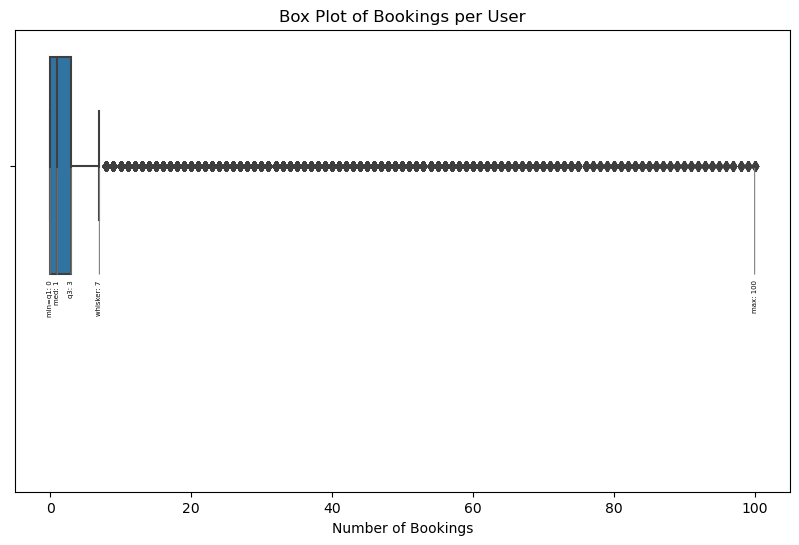

In [14]:
# IV. Defining "new user" from the distribution of bookings per user
user_bookings = hotel_rec_train.groupBy('user_id').agg(
    F.sum('is_booking').alias('num_bookings')
)
user_bookings_pd = user_bookings.select('num_bookings').toPandas()['num_bookings']

stats = user_bookings_pd.describe()
print(stats)
print()
print(f"Share of users with 0 bookings: {(user_bookings_pd == 0).mean():.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(user_bookings_pd, bins=30, kde=False)
plt.yscale('log')  # heavily right-skewed toward 0 bookings; log keeps the tail visible
plt.title('Distribution of Bookings per User')
plt.xlabel('Number of Bookings')
plt.ylabel('Number of Users (log scale)')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=user_bookings_pd, ax=ax)

iqr = stats['75%'] - stats['25%']
upper_fence = stats['75%'] + 1.5 * iqr
whisker_max = user_bookings_pd[user_bookings_pd <= upper_fence].max()

candidate_stats = {
    'min': stats['min'],
    'q1': stats['25%'],
    'med': stats['50%'],
    'q3': stats['75%'],
    'whisker': whisker_max,
    'max': stats['max'],
}

# Bookings per user is small-integer and likely zero-inflated, so several of these
# stats can land on the exact same value (e.g. min=q1=med=0) - group labels that
# coincide instead of stacking overlapping annotations on top of each other.
labels_by_value = {}
for label, value in candidate_stats.items():
    labels_by_value.setdefault(round(value), []).append(label)

for value, labels in sorted(labels_by_value.items()):
    ax.annotate(
        f"{'='.join(labels)}: {value}",
        xy=(value, 0),
        xytext=(value, -0.42),
        ha='right',
        va='center',
        rotation=90,
        fontsize=5,
        rotation_mode='anchor',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    )

ax.set_ylim(-1.2, 0.5)
ax.set_title('Box Plot of Bookings per User')
ax.set_xlabel('Number of Bookings')
plt.show()

# II.Yelp Dataset

In [ ]:
import json
import pandas as pd
ROLE_PATTERNS = {
    "review": "yelp_academic_dataset_review.json",
    "user": "yelp_academic_dataset_user.json",
    "business": "yelp_academic_dataset_business.json",
    "checkin": "yelp_academic_dataset_checkin.json",
    "tip": "yelp_academic_dataset_tip.json",
}

review_df = spark.read.json(os.path.join(yelp_review_path, ROLE_PATTERNS["review"]))
user_df = spark.read.json(os.path.join(yelp_review_path, ROLE_PATTERNS["user"]))
business_df = spark.read.json(os.path.join(yelp_review_path, ROLE_PATTERNS["business"]))
checkin_df = spark.read.json(os.path.join(yelp_review_path, ROLE_PATTERNS["checkin"]))
tip_df = spark.read.json(os.path.join(yelp_review_path, ROLE_PATTERNS["tip"]))

In [ ]:
review_df.describe().show()

26/09/18 16:51:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [6]:
checkin_df.show()

+--------------------+--------------------+
|         business_id|                date|
+--------------------+--------------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|
|--8IbOsAAxjKRoYsB...|2015-06-06 01:03:...|
|--9osgUCSDUWUkoTL...|2015-06-13 02:00:...|
|--ARBQr1WMsTWiwOK...|2014-12-12 00:44:...|
|--FWWsIwxRwuw9vIM...|2010-09-11 16:28:...|
|--FcbSxK1AoEtEAxO...|2017-08-18 19:43:...|
|--LC8cIrALInl2vyo...|2017-01-12 19:10:...|
|--MbOh2O1pATkXa7x...|2013-04-21 01:52:...|
|--N9yp3ZWqQIm7DqK...|2012-10-06 20:46:...|
|--O3ip9NpXTKD4oBS...|2010-04-17 21:07:...|
|--OS_I7dnABrXvRCC...| 2018-05-11 18:23:36|
|--S43ruInmIsGrnnk...|2010-08-29 01:17:...|
|--SJXpAa0E-GCp2sm...|2014-04-06 22:23:...|
|--Sd93OFWITqDHifM...|2013-01-09 17:42:...|
|--ZVrH2X2QXBFdCil...|2010-08-12 18:21:...|
|--ZWv8kGlM2YL58uK...|2010-10-13

In [7]:
business_df.show()

+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+-------+-------------+--------------+--------------------+-----------+------------+-----+-----+
|             address|          attributes|         business_id|          categories|          city|               hours|is_open|     latitude|     longitude|                name|postal_code|review_count|stars|state|
+--------------------+--------------------+--------------------+--------------------+--------------+--------------------+-------+-------------+--------------+--------------------+-----------+------------+-----+-----+
|1616 Chapala St, ...|{NULL, NULL, NULL...|Pns2l4eNsfO8kk83d...|Doctors, Traditio...| Santa Barbara|                NULL|      0|   34.4266787|  -119.7111968|Abby Rappoport, L...|      93101|           7|  5.0|   CA|
|87 Grasso Plaza S...|{NULL, NULL, NULL...|mpf3x-BjTdTEA3yCZ...|Shipping Centers,...|        Affton|{8:0-18:30, 0:0-0...|      1|   

In [17]:
business_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

In [18]:
tip_df.show(truncate=False)

+----------------------+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------+
|business_id           |compliment_count|date               |text                                                                                                                                                                                                        |user_id               |
+----------------------+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------+
|3uLgwr0qeCNMjKenHJwPGQ|0               |2012-05-18 02:17:21|Avengers time with the ladies.                                       

In [13]:
user_df.show()

+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+-----+--------------------+----+--------------------+-----+---------+------------+------+--------------------+-------------------+
|average_stars|compliment_cool|compliment_cute|compliment_funny|compliment_hot|compliment_list|compliment_more|compliment_note|compliment_photos|compliment_plain|compliment_profile|compliment_writer| cool|               elite|fans|             friends|funny|     name|review_count|useful|             user_id|      yelping_since|
+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+-----+--------------------+----+--------------------+-----+---------+------------+------+--------------------+-------------------+
|         

In [11]:
def duplicate_report(df, name, key_cols=None):
    total = df.count()
    distinct_all = df.dropDuplicates().count()
    print(f"[{name}] rows: {total:,} | exact duplicate rows (all columns): {total - distinct_all:,}")
    if key_cols:
        distinct_key = df.dropDuplicates(key_cols).count()
        print(f"[{name}] duplicates on key {key_cols}: {total - distinct_key:,}")
    print()

duplicate_report(review_df, "review_df", key_cols=["review_id"])
duplicate_report(tip_df, "tip_df", key_cols=["business_id", "user_id", "date", "text"])
duplicate_report(checkin_df, "checkin_df", key_cols=["business_id"])

[review_df] rows: 6,990,280 | exact duplicate rows (all columns): 0


[review_df] duplicates on key ['review_id']: 0



[tip_df] rows: 908,915 | exact duplicate rows (all columns): 67


[tip_df] duplicates on key ['business_id', 'user_id', 'date', 'text']: 67



[checkin_df] rows: 131,930 | exact duplicate rows (all columns): 0


[checkin_df] duplicates on key ['business_id']: 0



In [12]:
# Cross-table: does the exact same (business_id, user_id, date, text) show up
# in BOTH review_df and tip_df (i.e. the same interaction recorded twice)?
shared_cols = ["business_id", "user_id", "date", "text"]
overlap_review_tip = review_df.select(*shared_cols).intersect(tip_df.select(*shared_cols))
print(f"Rows identical in review_df and tip_df on {shared_cols}: {overlap_review_tip.count():,}")

Rows identical in review_df and tip_df on ['business_id', 'user_id', 'date', 'text']: 0


In [10]:
# business_id coverage across the three tables (checkin_df has no user_id/text,
# so this is the only meaningful cross-table check for it)
review_biz = review_df.select("business_id").distinct()
tip_biz = tip_df.select("business_id").distinct()
checkin_biz = checkin_df.select("business_id").distinct()

print(f"Distinct business_id -> review: {review_biz.count():,} | tip: {tip_biz.count():,} | checkin: {checkin_biz.count():,}")
print(f"In review & tip: {review_biz.intersect(tip_biz).count():,}")
print(f"In review & checkin: {review_biz.intersect(checkin_biz).count():,}")
print(f"In tip & checkin: {tip_biz.intersect(checkin_biz).count():,}")
print(f"In all three: {review_biz.intersect(tip_biz).intersect(checkin_biz).count():,}")

Distinct business_id -> review: 150,346 | tip: 106,193 | checkin: 131,930


In review & tip: 106,193


In review & checkin: 131,930


In tip & checkin: 101,884


In all three: 101,884


In [14]:
business_df.select("attributes.*").printSchema()

root
 |-- AcceptsInsurance: string (nullable = true)
 |-- AgesAllowed: string (nullable = true)
 |-- Alcohol: string (nullable = true)
 |-- Ambience: string (nullable = true)
 |-- BYOB: string (nullable = true)
 |-- BYOBCorkage: string (nullable = true)
 |-- BestNights: string (nullable = true)
 |-- BikeParking: string (nullable = true)
 |-- BusinessAcceptsBitcoin: string (nullable = true)
 |-- BusinessAcceptsCreditCards: string (nullable = true)
 |-- BusinessParking: string (nullable = true)
 |-- ByAppointmentOnly: string (nullable = true)
 |-- Caters: string (nullable = true)
 |-- CoatCheck: string (nullable = true)
 |-- Corkage: string (nullable = true)
 |-- DietaryRestrictions: string (nullable = true)
 |-- DogsAllowed: string (nullable = true)
 |-- DriveThru: string (nullable = true)
 |-- GoodForDancing: string (nullable = true)
 |-- GoodForKids: string (nullable = true)
 |-- GoodForMeal: string (nullable = true)
 |-- HairSpecializesIn: string (nullable = true)
 |-- HappyHour: str

In [15]:
from pyspark.sql import functions as F

total = business_df.count()
attr_fields = business_df.select("attributes.*").columns
print(f"Number of attribute fields: {len(attr_fields)}")

coverage = business_df.select(
    *[F.count(F.col(f"attributes.{c}")).alias(c) for c in attr_fields]
).toPandas().T.rename(columns={0: "non_null_count"})
coverage["non_null_pct"] = (coverage["non_null_count"] / total * 100).round(1)
coverage.sort_values("non_null_pct", ascending=False)

Number of attribute fields: 39


,non_null_count,non_null_pct
BusinessAcceptsCreditCards,119765,79.7
BusinessParking,91085,60.6
RestaurantsPriceRange2,85314,56.7
BikeParking,72638,48.3
RestaurantsTakeOut,59857,39.8
WiFi,56914,37.9
RestaurantsDelivery,56282,37.4
GoodForKids,53375,35.5
OutdoorSeating,48802,32.5
RestaurantsReservations,45247,30.1


In [16]:
# attributes.* values are raw Python-repr strings from the Yelp export, not real
# booleans/JSON - e.g. "True"/"False"/"None", a quoted enum like "u'no'", or (for
# nested attributes such as BusinessParking/Ambience/GoodForMeal) a stringified
# Python dict rather than an actual nested struct. They need parsing before use.
business_df.select(
    "attributes.BusinessAcceptsCreditCards",
    "attributes.WiFi",
    "attributes.BusinessParking",
).distinct().show(10, truncate=False)

+--------------------------+-------+----------------------------------------------------------------------------------------+
|BusinessAcceptsCreditCards|WiFi   |BusinessParking                                                                         |
+--------------------------+-------+----------------------------------------------------------------------------------------+
|False                     |u'free'|{u'valet': False, u'garage': False, u'street': False, u'lot': True, u'validated': False}|
|True                      |'free' |{'garage': False, 'street': False, 'validated': None, 'lot': None, 'valet': False}      |
|True                      |'free' |{'garage': True, 'street': False, 'validated': True, 'lot': True, 'valet': False}       |
|True                      |u'free'|{u'valet': False, u'garage': None, u'street': True, u'lot': False, u'validated': None}  |
|True                      |'no'   |{u'valet': False, u'garage': False, u'street': None, u'lot': None, u'validated': N

In [19]:
# Businesses with attributes entirely missing
business_df.filter(F.col("attributes").isNull()).count()

13744

   stars    count    pct
0    1.0  1069561  15.30
1    2.0   544240   7.79
2    3.0   691934   9.90
3    4.0  1452918  20.78
4    5.0  3231627  46.23


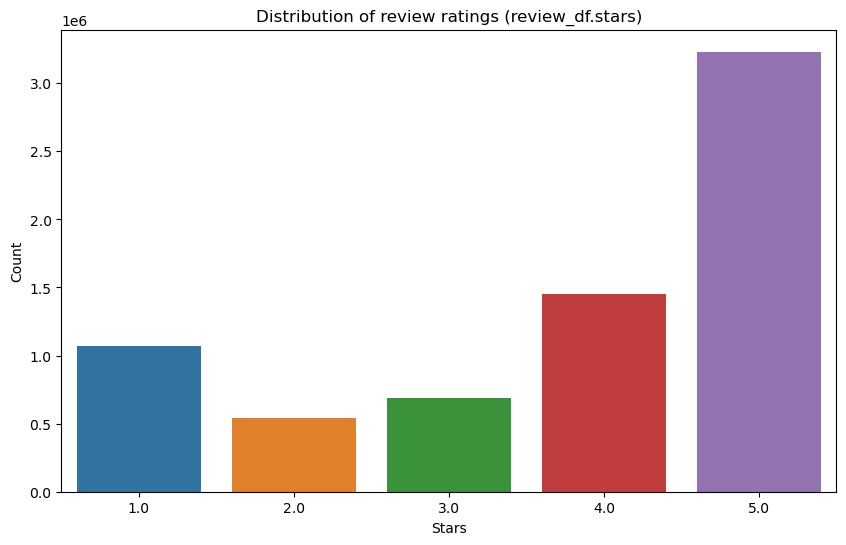

In [20]:
review_stars_dist = review_df.groupBy('stars').count().orderBy('stars').toPandas()
review_stars_dist['pct'] = (review_stars_dist['count'] / review_stars_dist['count'].sum() * 100).round(2)
print(review_stars_dist)

plt.figure(figsize=(10, 6))
sns.barplot(x='stars', y='count', data=review_stars_dist, order=sorted(review_stars_dist['stars']))
plt.title('Distribution of review ratings (review_df.stars)')
plt.xlabel('Stars')
plt.ylabel('Count')
plt.show()

   stars  count    pct
0    1.0   1986   1.32
1    1.5   4932   3.28
2    2.0   9527   6.34
3    2.5  14316   9.52
4    3.0  18453  12.27
5    3.5  26519  17.64
6    4.0  31125  20.70
7    4.5  27181  18.08
8    5.0  16307  10.85


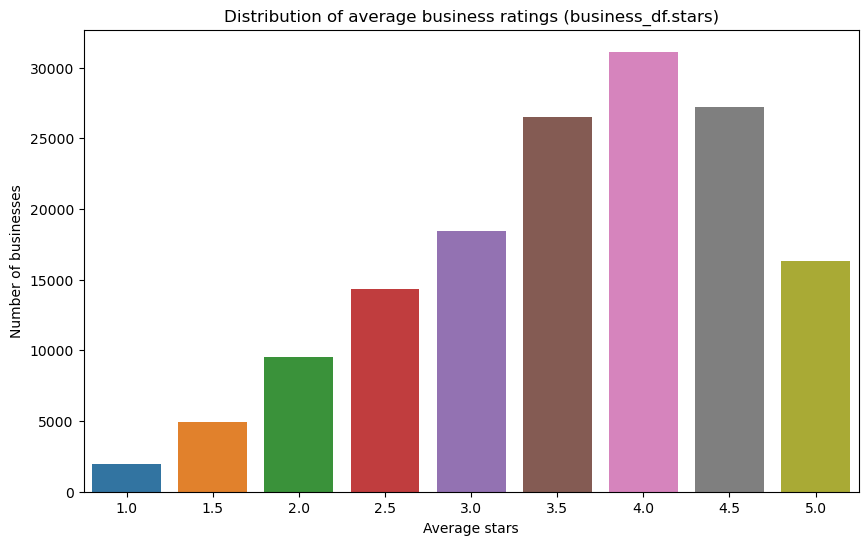

In [21]:
business_stars_dist = business_df.groupBy('stars').count().orderBy('stars').toPandas()
business_stars_dist['pct'] = (business_stars_dist['count'] / business_stars_dist['count'].sum() * 100).round(2)
print(business_stars_dist)

plt.figure(figsize=(10, 6))
sns.barplot(x='stars', y='count', data=business_stars_dist, order=sorted(business_stars_dist['stars']))
plt.title('Distribution of average business ratings (business_df.stars)')
plt.xlabel('Average stars')
plt.ylabel('Number of businesses')
plt.show()

count    1.987897e+06
mean     2.339441e+01
std      8.256699e+01
min      0.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.700000e+01
max      1.747300e+04
Name: review_count, dtype: float64

Share of users with exactly 1 review: 17.38%
Share of users with <=5 reviews: 50.46%


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


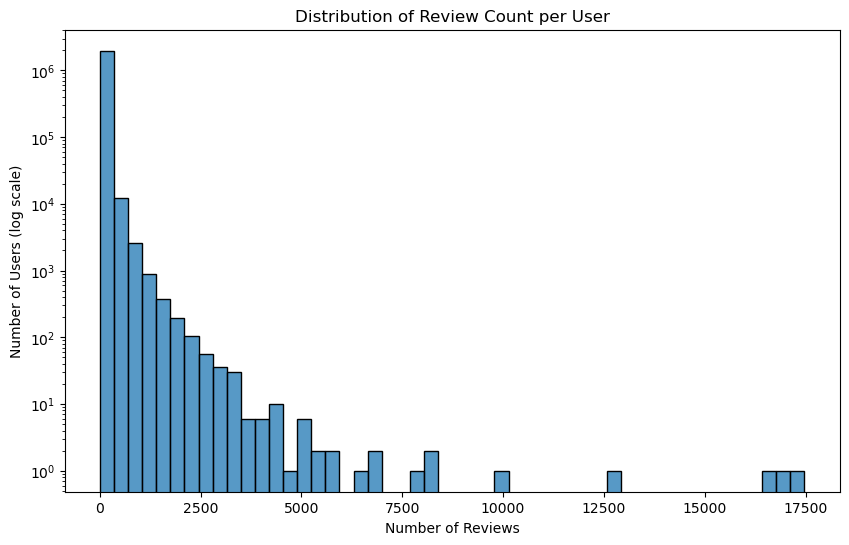

In [22]:
user_review_counts = user_df.select('review_count').toPandas()['review_count']

stats = user_review_counts.describe()
print(stats)
print()
print(f"Share of users with exactly 1 review: {(user_review_counts == 1).mean():.2%}")
print(f"Share of users with <=5 reviews: {(user_review_counts <= 5).mean():.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(user_review_counts, bins=50, kde=False)
plt.yscale('log')  # heavily right-skewed toward few reviews; log keeps the tail visible
plt.title('Distribution of Review Count per User')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users (log scale)')
plt.show()

In [30]:
new_users = user_df.select('review_count').filter(
    user_df['review_count'] <= 2
).count()
new_users

589235

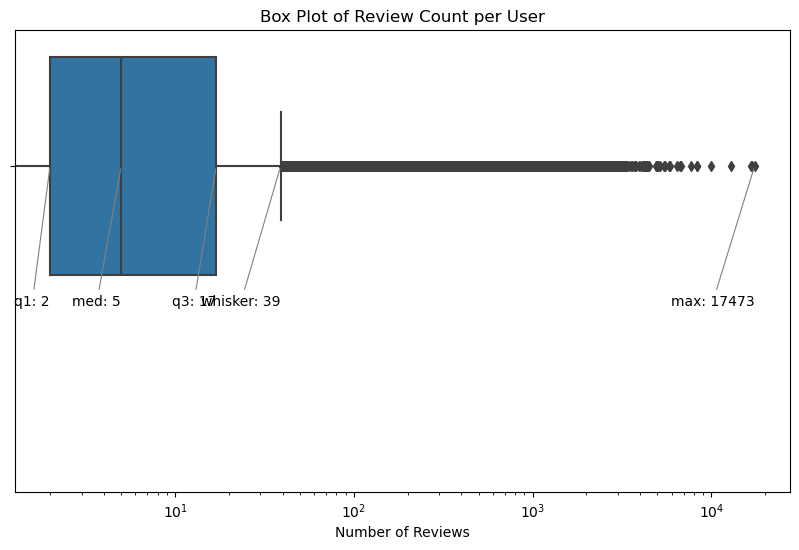

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x=user_review_counts, ax=ax)
ax.set_xscale('log') 

iqr = stats['75%'] - stats['25%']
upper_fence = stats['75%'] + 1.5 * iqr
whisker_max = user_review_counts[user_review_counts <= upper_fence].max()

candidate_stats = {
    'min': stats['min'],
    'q1': stats['25%'],
    'med': stats['50%'],
    'q3': stats['75%'],
    'whisker': whisker_max,
    'max': stats['max'],
}

# Review count is zero-inflated toward the low end, so several of these stats can
# land on the exact same value - group labels that coincide instead of stacking
# overlapping annotations on top of each other.
labels_by_value = {}
for label, value in candidate_stats.items():
    labels_by_value.setdefault(round(value), []).append(label)

for value, labels in sorted(labels_by_value.items()):
    ax.annotate(
        f"{'='.join(labels)}: {value}",
        xy=(value, 0),
        xytext=(value, -0.5),
        ha='right',
        va='center',
        rotation_mode='anchor',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
    )

ax.set_ylim(-1.2, 0.5)
ax.set_title('Box Plot of Review Count per User')
ax.set_xlabel('Number of Reviews')
plt.show()

    signup_year   count
0          2004      90
1          2005     937
2          2006    5423
3          2007   15340
4          2008   31097
5          2009   64911
6          2010  109054
7          2011  176435
8          2012  195955
9          2013  209762
10         2014  233465
11         2015  247850
12         2016  217620
13         2017  151024
14         2018  133568
15         2019  104655
16         2020   47444
17         2021   40485
18         2022    2782


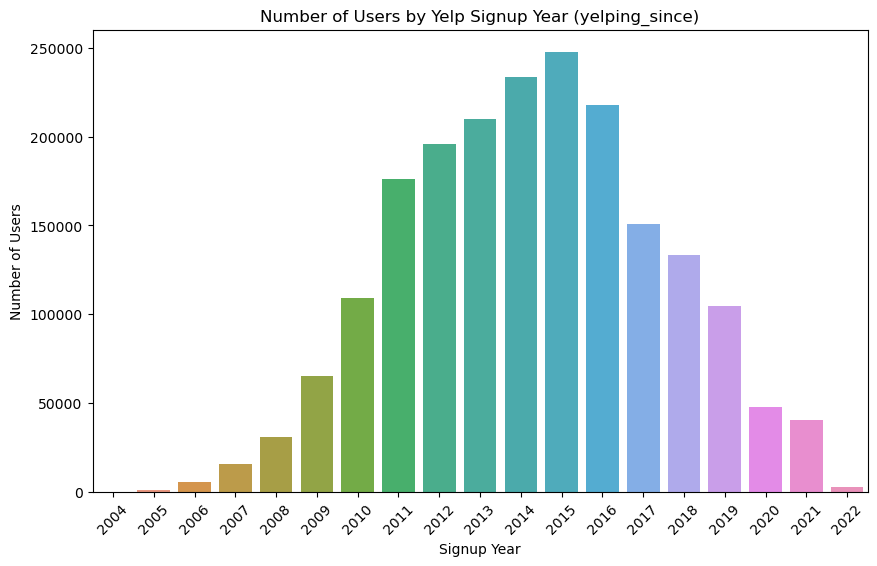

In [24]:
from pyspark.sql import functions as F

signup_year_dist = user_df.select(F.year('yelping_since').alias('signup_year')).groupBy('signup_year').count().orderBy('signup_year').toPandas()
print(signup_year_dist)

plt.figure(figsize=(10, 6))
sns.barplot(x='signup_year', y='count', data=signup_year_dist)
plt.title('Number of Users by Yelp Signup Year (yelping_since)')
plt.xlabel('Signup Year')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

In [31]:
from pyspark.sql import functions as F

business_categories = business_df.withColumn(
    'num_categories',
    F.when(F.col('categories').isNull(), 0).otherwise(F.size(F.split('categories', ',')))
).select('business_id', 'num_categories', 'review_count')

num_categories_pd = business_categories.select('num_categories').toPandas()['num_categories']
print(num_categories_pd.describe())
print()
print(f"Businesses with no categories listed: {(num_categories_pd == 0).sum():,}")

count    150346.000000
mean          4.447022
std           2.233734
min           0.000000
25%           3.000000
50%           4.000000
75%           6.000000
max          36.000000
Name: num_categories, dtype: float64

Businesses with no categories listed: 103


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


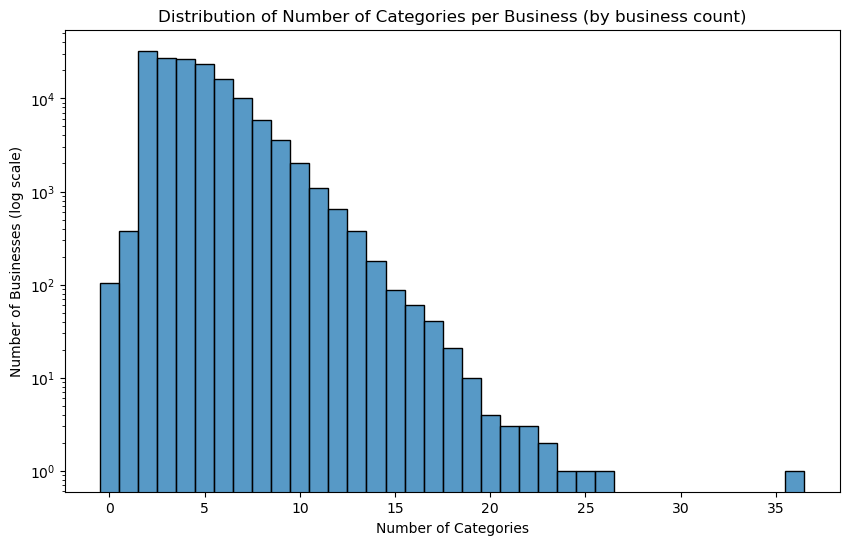

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(num_categories_pd, bins=range(0, num_categories_pd.max() + 2), discrete=True)
plt.yscale('log')  # right-skewed: most businesses have a handful of categories, few have many
plt.title('Distribution of Number of Categories per Business (by business count)')
plt.xlabel('Number of Categories')
plt.ylabel('Number of Businesses (log scale)')
plt.show()

    num_categories  num_businesses  total_reviews  pct_businesses  pct_reviews
0                0             103            668            0.07         0.01
1                1             381           5129            0.25         0.08
2                2           32563        1014499           21.66        15.04
3                3           27065         907196           18.00        13.45
4                4           26354        1154419           17.53        17.11
5                5           23450        1044722           15.60        15.49
6                6           16233         852784           10.80        12.64
7                7           10189         619683            6.78         9.19
8                8            5869         429241            3.90         6.36
9                9            3598         282028            2.39         4.18
10              10            2024         165031            1.35         2.45
11              11            1083         108786   

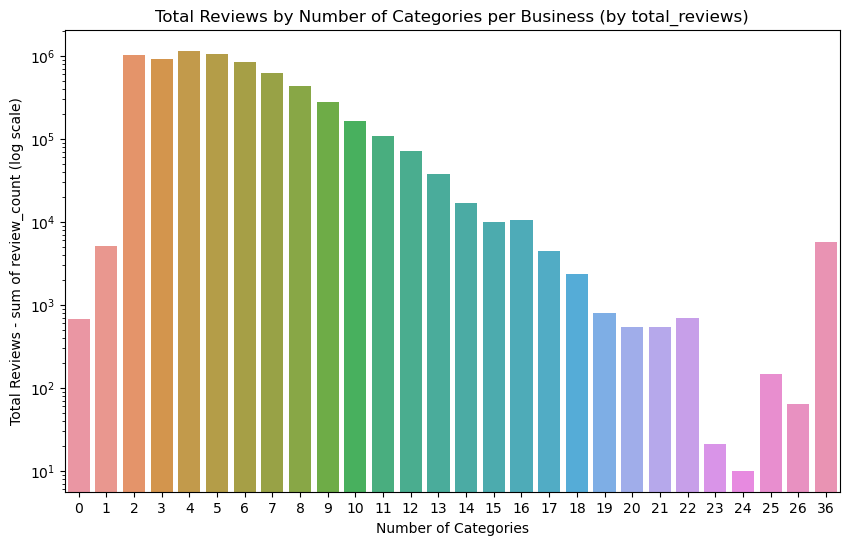

In [33]:
cat_count_agg = business_categories.groupBy('num_categories').agg(
    F.count('business_id').alias('num_businesses'),
    F.sum('review_count').alias('total_reviews'),
).orderBy('num_categories').toPandas()

cat_count_agg['pct_businesses'] = (cat_count_agg['num_businesses'] / cat_count_agg['num_businesses'].sum() * 100).round(2)
cat_count_agg['pct_reviews'] = (cat_count_agg['total_reviews'] / cat_count_agg['total_reviews'].sum() * 100).round(2)
print(cat_count_agg)

plt.figure(figsize=(10, 6))
sns.barplot(x='num_categories', y='total_reviews', data=cat_count_agg)
plt.yscale('log')
plt.title('Total Reviews by Number of Categories per Business (by total_reviews)')
plt.xlabel('Number of Categories')
plt.ylabel('Total Reviews - sum of review_count (log scale)')
plt.show()

In [35]:
category_list = (
    business_df
    .withColumn('categories_arr', F.split(F.col('categories'), ','))
    .withColumn('category', F.explode('categories_arr'))
    .withColumn('category', F.trim(F.col('category')))
    .groupBy('category')
    .agg(
        F.count('business_id').alias('num_businesses'),
        F.sum('review_count').alias('total_reviews'),
    )
    .orderBy(F.desc('num_businesses'))
)

print(f"Total distinct categories: {category_list.count():,}")
category_list_pd = category_list.toPandas()
category_list_pd

Total distinct categories: 1,311


,category,num_businesses,total_reviews
0,Restaurants,52268,4561279
1,Food,27781,1752281
2,Shopping,24395,505372
3,Home Services,14356,226962
4,Beauty & Spas,14292,354203
...,...,...,...
1306,Trade Fairs,1,11
1307,Hospitalists,1,31
1308,Natural Gas Suppliers,1,7
1309,Ceremonial Clothing,1,5


In [ ]:
restaurant_ids = business_df.filter(F.array_contains(F.split(F.col('categories'), ', '), 'Restaurants')).select('business_id')

restaurant_reviews = review_df.join(restaurant_ids, on='business_id', how='inner')
restaurant_reviews.persist()

n_restaurant_reviews = restaurant_reviews.count()
n_users_reviewing_restaurants = restaurant_reviews.select('user_id').distinct().count()
print(f"Reviews on Restaurants-category businesses: {n_restaurant_reviews:,} ({n_restaurant_reviews / review_df.count():.2%} of all reviews)")
print(f"Distinct users who reviewed a restaurant: {n_users_reviewing_restaurants:,}")

star_dist = restaurant_reviews.groupBy('stars').count().orderBy('stars').toPandas()
star_dist['pct'] = (star_dist['count'] / star_dist['count'].sum() * 100).round(2)
print(star_dist)
print(f"Average star: {restaurant_reviews.agg(F.avg('stars')).collect()[0][0]:.3f}")


In [ ]:
# Per-user review count restricted to restaurants only (not user_df's global
# review_count, which also counts non-restaurant reviews) - this is the relevant
# "new user" denominator for a restaurant recommender.
user_restaurant_counts = restaurant_reviews.groupBy('user_id').count().withColumnRenamed('count', 'n_restaurant_reviews')
user_restaurant_counts.persist()

for th in [1, 2, 3]:
    n = user_restaurant_counts.filter(F.col('n_restaurant_reviews') <= th).count()
    print(f"Users with <= {th} restaurant review(s): {n:,} ({n / n_users_reviewing_restaurants:.2%})")

stats = user_restaurant_counts.agg(
    F.min('n_restaurant_reviews'),
    F.expr('percentile_approx(n_restaurant_reviews, 0.5)'),
    F.avg('n_restaurant_reviews'),
    F.max('n_restaurant_reviews'),
).collect()[0]
print(f"\nmin={stats[0]}, median={stats[1]}, mean={stats[2]:.2f}, max={stats[3]}")
